# Figure: rating-group transition curves and country composition

This notebook uses `master_data.rds` for the 2026 project map and country-composition panel and the fitted **Core + macro controls + year FE** Figure 2 models for transition analysis.

The main figure contains a global project map, three cumulative progression panels evaluated at rating-group median `Country_Risk_Spread_log` values and compared with the model-based sample average, and a country-composition panel. Prediction profiles assign every model observation the median country-risk value of the indicated rating group while keeping all other covariates at their observed values. The composition panel uses one project-level record, colours countries by region, and labels the five largest countries in each rating group.

The final section generates **Supplementary Figure S5: Competing risk model Regions** from `multinomial_competing_risk_results.rds`. Run `Discrete-Time-Multinomial-Competing-Risk-Model.ipynb` first.

The fitted country/macro models used here inherit the governance control selected in the master pipeline (`Governance_Score`, `Ease_of_doing_business`, or none).


In [1]:
# Use the same project/data directory in standalone and master-run execution.
# With H2_PROJECT_DIR unset, run from the folder containing Data/ and the RDS files.
project_dir <- Sys.getenv("H2_PROJECT_DIR", unset = getwd())
project_dir <- normalizePath(project_dir, winslash = "/", mustWork = TRUE)
setwd(project_dir)


In [2]:
# ==============================================================================
# Packages and Figure2 inputs
# ==============================================================================

required_packages <- c(
  "dplyr",
  "tidyr",
  "purrr",
  "sandwich",
  "ggplot2",
  "ggsci",
  "scales",
  "patchwork",
  "MASS",
  "stringr",
  "tibble"
)

missing_packages <- required_packages[
  !vapply(
    required_packages,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]

if (length(missing_packages) > 0) {
  stop(
    paste0(
      "Missing packages: ",
      paste(missing_packages, collapse = ", "),
      ". Install them before running this notebook."
    )
  )
}

invisible(
  lapply(
    required_packages,
    library,
    character.only = TRUE
  )
)

set.seed(123)


# ------------------------------------------------------------------------------
# Load the project-level data and the shared Figure2 model data
# ------------------------------------------------------------------------------

master_data_file <- "master_data.rds"
model_data_file <- "cloglog_data_processed.rds"

for (required_file in c(master_data_file, model_data_file)) {
  if (!file.exists(required_file)) {
    stop(
      paste0(
        "The required input file '",
        required_file,
        "' was not found. Run Data Preparation before this notebook."
      )
    )
  }
}

master_data <- readRDS(master_data_file)
cloglog_data <- readRDS(model_data_file)

# ------------------------------------------------------------------------------
# Load the exact fitted models produced by Figure2
# ------------------------------------------------------------------------------

model_results_file <- "waterfall_results.rds"

if (!file.exists(model_results_file)) {
  stop(
    paste0(
      "The Figure2 model-results file '",
      model_results_file,
      "' was not found. Run Figure2 before this notebook."
    )
  )
}

figure2_results <- readRDS(model_results_file)

transition_names <- c(
  "Concept -> Progress",
  "Feasibility -> Progress",
  "FID -> Progress"
)

full_model_name <- "Core + macro controls + year FE"

extract_figure2_models <- function(
    results,
    transitions,
    model_name
) {
  extracted_models <- lapply(
    transitions,
    function(transition_name) {
      transition_models <- results$models[[transition_name]]

      if (is.null(transition_models)) {
        stop(
          paste0(
            "Transition '",
            transition_name,
            "' was not found in ",
            model_results_file,
            "."
          )
        )
      }

      model_obj <- transition_models[[model_name]]

      if (is.null(model_obj) || is.null(model_obj$model)) {
        stop(
          paste0(
            "Model '",
            model_name,
            "' was not available for ",
            transition_name,
            "."
          )
        )
      }

      model_obj
    }
  )

  names(extracted_models) <- transitions

  list(
    models = extracted_models
  )
}

cloglog_results_full <- extract_figure2_models(
  results = figure2_results,
  transitions = transition_names,
  model_name = full_model_name
)


# ------------------------------------------------------------------------------
# Preferred regional display order
#
# The display order lists supported region categories. Categories absent from
# the data are omitted from the figure.
# ------------------------------------------------------------------------------

region_order <- c(
  "Europe",
  "US + Canada",
  "Asia Pacific",
  "Latin America",
  "Africa + Middle East"
)


Warning message:
“package ‘dplyr’ was built under R version 4.5.3”



Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Warning message:
“package ‘purrr’ was built under R version 4.5.3”


...

The following object is masked from ‘package:purrr’:

    discard




Warning message:
“package ‘MASS’ was built under R version 4.5.3”



Attaching package: ‘MASS’




The following object is masked from ‘package:patchwork’:

    area




The following object is masked from ‘package:dplyr’:

    select




## Shared functions for the rating-group figure

This section defines the plotting and standardised prediction functions used by the four aggregated rating groups.


In [3]:
# ------------------------------------------------------------------------------
# Shared plotting and prediction helpers
# ------------------------------------------------------------------------------

first_non_missing_character <- function(x) {
  x <- stringr::str_squish(
    as.character(x)
  )

  x <- x[
    !is.na(x) &
      x != ""
  ]

  if (length(x) == 0) {
    return(NA_character_)
  }

  x[[1]]
}


make_npg_palette <- function(levels) {
  levels <- as.character(levels)
  levels <- levels[
    !is.na(levels) &
      levels != ""
  ]

  if (length(levels) == 0) {
    return(
      stats::setNames(
        character(0),
        character(0)
      )
    )
  }

  base_colours <- ggsci::pal_npg()(10)

  selected_colours <- if (
    length(levels) <= length(base_colours)
  ) {
    base_colours[seq_along(levels)]
  } else {
    grDevices::colorRampPalette(base_colours)(
      length(levels)
    )
  }

  stats::setNames(
    selected_colours,
    levels
  )
}


base_theme <- theme_minimal(
  base_size = 12.75
) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.line.y.left = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.x = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.y = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.length = grid::unit(
      1.5,
      "mm"
    ),
    plot.title = element_text(
      hjust = 0,
      face = "plain",
      size = 14.25,
      margin = margin(b = 4)
    ),
    axis.text = element_text(
      size = 11.25
    ),
    axis.title = element_text(
      size = 12
    ),
    strip.text = element_text(
      size = 11.25,
      face = "plain",
      margin = margin(b = 2)
    ),
    plot.margin = margin(
      5,
      5,
      5,
      5
    )
  )


make_psd <- function(x) {
  x <- (x + t(x)) / 2
  x[!is.finite(x)] <- 0

  eig <- eigen(
    x,
    symmetric = TRUE
  )

  eig$values <- pmax(
    eig$values,
    .Machine$double.eps
  )

  eig$vectors %*%
    diag(
      eig$values,
      nrow = length(eig$values)
    ) %*%
    t(eig$vectors)
}


make_coef_draws <- function(
    model,
    model_data,
    n_draws = 300
) {
  beta_hat <- stats::coef(model)
  beta_hat <- beta_hat[
    is.finite(beta_hat)
  ]

  vcov_mat <- sandwich::vcovCL(
    model,
    cluster = ~ reference,
    data = model_data
  )

  coef_names <- intersect(
    names(beta_hat),
    rownames(vcov_mat)
  )

  beta_hat <- beta_hat[coef_names]
  vcov_mat <- vcov_mat[
    coef_names,
    coef_names,
    drop = FALSE
  ]

  draws <- MASS::mvrnorm(
    n = n_draws,
    mu = beta_hat,
    Sigma = make_psd(vcov_mat)
  )

  draws <- as.matrix(draws)
  colnames(draws) <- names(beta_hat)
  draws
}


predict_individual_hazard_draws <- function(
    model,
    pred_data,
    coef_draws
) {
  coef_names <- colnames(coef_draws)

  beta_hat <- stats::coef(model)
  beta_hat <- beta_hat[coef_names]

  x_mat <- stats::model.matrix(
    stats::delete.response(stats::terms(model)),
    data = pred_data
  )

  missing_cols <- setdiff(
    coef_names,
    colnames(x_mat)
  )

  if (length(missing_cols) > 0) {
    missing_mat <- matrix(
      0,
      nrow = nrow(x_mat),
      ncol = length(missing_cols)
    )

    colnames(missing_mat) <- missing_cols

    x_mat <- cbind(
      x_mat,
      missing_mat
    )
  }

  x_mat <- x_mat[, coef_names, drop = FALSE]
  linkinv <- stats::family(model)$linkinv

  hazard_hat <- as.numeric(
    linkinv(
      drop(x_mat %*% beta_hat)
    )
  )

  eta_draws <- x_mat %*%
    t(
      coef_draws[, coef_names, drop = FALSE]
    )

  hazard_draws <- matrix(
    linkinv(as.numeric(eta_draws)),
    nrow = nrow(eta_draws),
    ncol = ncol(eta_draws)
  )

  list(
    hazard_hat = hazard_hat,
    hazard_draws = hazard_draws
  )
}


make_standardised_cloglog_curve <- function(
    model,
    pred_base,
    time_grid,
    time_scale,
    coef_draws,
    time_var = "prev_time_in_status",
    raw_time_var = "prev_time_in_status_raw",
    conf_level = 0.90
) {
  if (nrow(pred_base) == 0) {
    return(NULL)
  }

  alpha <- 1 - conf_level
  number_of_draws <- nrow(coef_draws)

  survival_hat <- rep(
    1,
    nrow(pred_base)
  )

  survival_draws <- matrix(
    1,
    nrow = nrow(pred_base),
    ncol = number_of_draws
  )

  annual_hazard <- numeric(
    length(time_grid)
  )

  cumulative_hat <- numeric(
    length(time_grid)
  )

  cumulative_draw_mat <- matrix(
    NA_real_,
    nrow = length(time_grid),
    ncol = number_of_draws
  )

  for (i in seq_along(time_grid)) {
    pred_data <- pred_base
    pred_data[[raw_time_var]] <- time_grid[i]
    pred_data[[time_var]] <- apply_time_scale(
      time_raw = time_grid[i],
      time_scale = time_scale
    )

    pred <- predict_individual_hazard_draws(
      model = model,
      pred_data = pred_data,
      coef_draws = coef_draws
    )

    hazard_hat <- pmin(
      pmax(pred$hazard_hat, 0),
      1
    )

    hazard_draws <- pmin(
      pmax(pred$hazard_draws, 0),
      1
    )

    survival_hat <- survival_hat * (
      1 - hazard_hat
    )

    survival_draws <- survival_draws * (
      1 - hazard_draws
    )

    annual_hazard[i] <- mean(
      hazard_hat,
      na.rm = TRUE
    )

    cumulative_hat[i] <- mean(
      1 - survival_hat,
      na.rm = TRUE
    )

    cumulative_draw_mat[i, ] <- colMeans(
      1 - survival_draws,
      na.rm = TRUE
    )
  }

  ci_mat <- t(
    apply(
      cumulative_draw_mat,
      1,
      stats::quantile,
      probs = c(
        alpha / 2,
        1 - alpha / 2
      ),
      na.rm = TRUE
    )
  )

  dplyr::bind_rows(
    tibble::tibble(
      time = 0,
      annual_hazard = NA_real_,
      cumulative_transition_probability = 0,
      conf_low = 0,
      conf_high = 0
    ),
    tibble::tibble(
      time = time_grid,
      annual_hazard = annual_hazard,
      cumulative_transition_probability = cumulative_hat,
      conf_low = ci_mat[, 1],
      conf_high = ci_mat[, 2]
    )
  )
}


# Build the x-axis in calendar years and recover the exact linear mapping from
# the stored raw duration to the covariate scale used in the fitted model.
make_time_grid <- function(
    model_data,
    time_var,
    raw_time_var = "prev_time_in_status_raw"
) {
  if (!all(c(time_var, raw_time_var) %in% names(model_data))) {
    stop(
      paste0(
        "The fitted model data must contain both '",
        time_var,
        "' and '",
        raw_time_var,
        "'. Re-run Data Preparation and Figure2."
      )
    )
  }

  max_time <- max(
    model_data[[raw_time_var]],
    na.rm = TRUE
  )

  if (!is.finite(max_time) || max_time < 1) {
    return(NULL)
  }

  seq(
    from = 1,
    to = ceiling(max_time),
    by = 1
  )
}


get_time_scale <- function(
    model_data,
    time_var,
    raw_time_var = "prev_time_in_status_raw"
) {
  time_mapping <- model_data %>%
    dplyr::transmute(
      time_model = as.numeric(.data[[time_var]]),
      time_raw = as.numeric(.data[[raw_time_var]])
    ) %>%
    dplyr::filter(
      is.finite(time_model),
      is.finite(time_raw)
    ) %>%
    dplyr::distinct()

  if (dplyr::n_distinct(time_mapping$time_raw) < 2) {
    stop(
      "At least two raw duration values are required to recover the model scale."
    )
  }

  mapping_model <- stats::lm(
    time_model ~ time_raw,
    data = time_mapping
  )

  c(
    intercept = unname(stats::coef(mapping_model)[[1]]),
    slope = unname(stats::coef(mapping_model)[[2]])
  )
}


apply_time_scale <- function(
    time_raw,
    time_scale
) {
  unname(
    time_scale[["intercept"]] +
      time_scale[["slope"]] * time_raw
  )
}


make_step_ribbon_data <- function(
    data,
    group_vars
) {
  if (nrow(data) == 0) {
    return(data)
  }

  value_cols <- c(
    "annual_hazard",
    "cumulative_transition_probability",
    "conf_low",
    "conf_high"
  )

  data %>%
    dplyr::arrange(
      dplyr::across(
        dplyr::all_of(
          c(
            group_vars,
            "time"
          )
        )
      )
    ) %>%
    dplyr::group_by(
      dplyr::across(
        dplyr::all_of(group_vars)
      )
    ) %>%
    dplyr::group_modify(
      function(.x, .y) {
        .x <- .x %>%
          dplyr::arrange(time)

        if (nrow(.x) <= 1) {
          return(.x)
        }

        out <- .x[1, , drop = FALSE]

        for (i in 2:nrow(.x)) {
          previous_row <- .x[i - 1, , drop = FALSE]
          current_row <- .x[i, , drop = FALSE]
          step_row <- current_row
          step_row[value_cols] <- previous_row[value_cols]

          out <- dplyr::bind_rows(
            out,
            step_row,
            current_row
          )
        }

        out
      }
    ) %>%
    dplyr::ungroup()
}


make_transition_rating_group_and_average_curves <- function(
    cloglog_results,
    transition_name,
    rating_profiles,
    time_var = "prev_time_in_status",
    risk_var = "Country_Risk_Spread_log",
    n_draws = 300,
    conf_level = 0.90
) {
  model_obj <- cloglog_results$models[[transition_name]]

  if (is.null(model_obj)) {
    return(NULL)
  }

  model <- model_obj$model
  model_data <- model_obj$data

  model_terms <- gsub(
    "`",
    "",
    attr(stats::terms(model), "term.labels")
  )

  if (!risk_var %in% names(model_data) ||
      !any(
        stringr::str_detect(
          model_terms,
          stringr::fixed(risk_var)
        )
      )) {
    stop(
      paste0(
        "The fitted model for ",
        transition_name,
        " does not contain '",
        risk_var,
        "'."
      )
    )
  }

  time_grid <- make_time_grid(
    model_data = model_data,
    time_var = time_var
  )

  if (is.null(time_grid)) {
    return(NULL)
  }

  time_scale <- get_time_scale(
    model_data = model_data,
    time_var = time_var,
    raw_time_var = raw_time_var
  )

  coef_draws <- make_coef_draws(
    model = model,
    model_data = model_data,
    n_draws = n_draws
  )

  make_curve <- function(pred_base) {
    make_standardised_cloglog_curve(
      model = model,
      pred_base = pred_base,
      time_grid = time_grid,
      time_scale = time_scale,
      coef_draws = coef_draws,
      time_var = time_var,
      raw_time_var = raw_time_var,
      conf_level = conf_level
    )
  }

  average_curve <- make_curve(
    model_data
  ) %>%
    dplyr::mutate(
      transition = transition_name,
      curve_type = "Sample average"
    )

  rating_group_curves <- purrr::pmap_dfr(
    list(
      as.character(rating_profiles$rating_group),
      as.character(rating_profiles$rating_group_label),
      rating_profiles$risk_value
    ),
    function(rating_group, rating_group_label, risk_value) {
      pred_base <- model_data
      pred_base[[risk_var]] <- rep(
        risk_value,
        nrow(pred_base)
      )

      make_curve(pred_base) %>%
        dplyr::mutate(
          transition = transition_name,
          rating_group = rating_group,
          rating_group_label = rating_group_label,
          risk_value = risk_value,
          curve_type = "Rating-group"
        )
    }
  ) %>%
    dplyr::mutate(
      rating_group = factor(
        rating_group,
        levels = rating_group_levels
      ),
      rating_group_label = factor(
        rating_group_label,
        levels = unname(
          rating_group_labels[rating_group_levels]
        )
      )
    )

  list(
    rating_group_curves = rating_group_curves,
    average_curve = average_curve
  )
}


make_rating_group_average_plot_data <- function(
    transition_name,
    rating_group_curve_data,
    average_curve_data,
    rating_profiles
) {
  transition_risk_data <- rating_group_curve_data %>%
    dplyr::filter(
      transition == transition_name
    )

  transition_average_data <- average_curve_data %>%
    dplyr::filter(
      transition == transition_name
    )

  average_expanded <- purrr::pmap_dfr(
    list(
      as.character(rating_profiles$rating_group),
      as.character(rating_profiles$rating_group_label),
      rating_profiles$risk_value
    ),
    function(rating_group, rating_group_label, risk_value) {
      transition_average_data %>%
        dplyr::mutate(
          rating_group = rating_group,
          rating_group_label = rating_group_label,
          risk_value = risk_value
        )
    }
  ) %>%
    dplyr::mutate(
      rating_group = factor(
        rating_group,
        levels = rating_group_levels
      ),
      rating_group_label = factor(
        rating_group_label,
        levels = unname(
          rating_group_labels[rating_group_levels]
        )
      )
    )

  risk_final <- transition_risk_data %>%
    dplyr::group_by(
      rating_group,
      rating_group_label
    ) %>%
    dplyr::slice_max(
      time,
      n = 1,
      with_ties = FALSE
    ) %>%
    dplyr::ungroup() %>%
    dplyr::select(
      rating_group,
      rating_group_label,
      time,
      risk_probability = cumulative_transition_probability,
      risk_conf_high = conf_high
    )

  average_final <- transition_average_data %>%
    dplyr::slice_max(
      time,
      n = 1,
      with_ties = FALSE
    ) %>%
    dplyr::transmute(
      average_probability = cumulative_transition_probability,
      average_conf_high = conf_high
    )

  label_data <- risk_final %>%
    dplyr::mutate(
      average_probability = average_final$average_probability[[1]],
      average_conf_high = average_final$average_conf_high[[1]],
      difference_pp = 100 * (
        risk_probability - average_probability
      ),
      label = paste0(
        "Δ vs avg. ",
        sprintf(
          "%+.1f",
          difference_pp
        ),
        " pp"
      ),
      label_y = pmax(
        risk_probability,
        average_probability,
        risk_conf_high,
        average_conf_high,
        na.rm = TRUE
      )
    )

  list(
    risk_data = transition_risk_data,
    average_data = average_expanded,
    label_data = label_data
  )
}


## Figure construction, country composition, and export

The A4 portrait figure places the global map across the top, followed by three rating-group comparison rows and a 100% stacked country-composition chart. Countries are separate segments and are coloured by region; the five largest countries within each rating group are labelled.


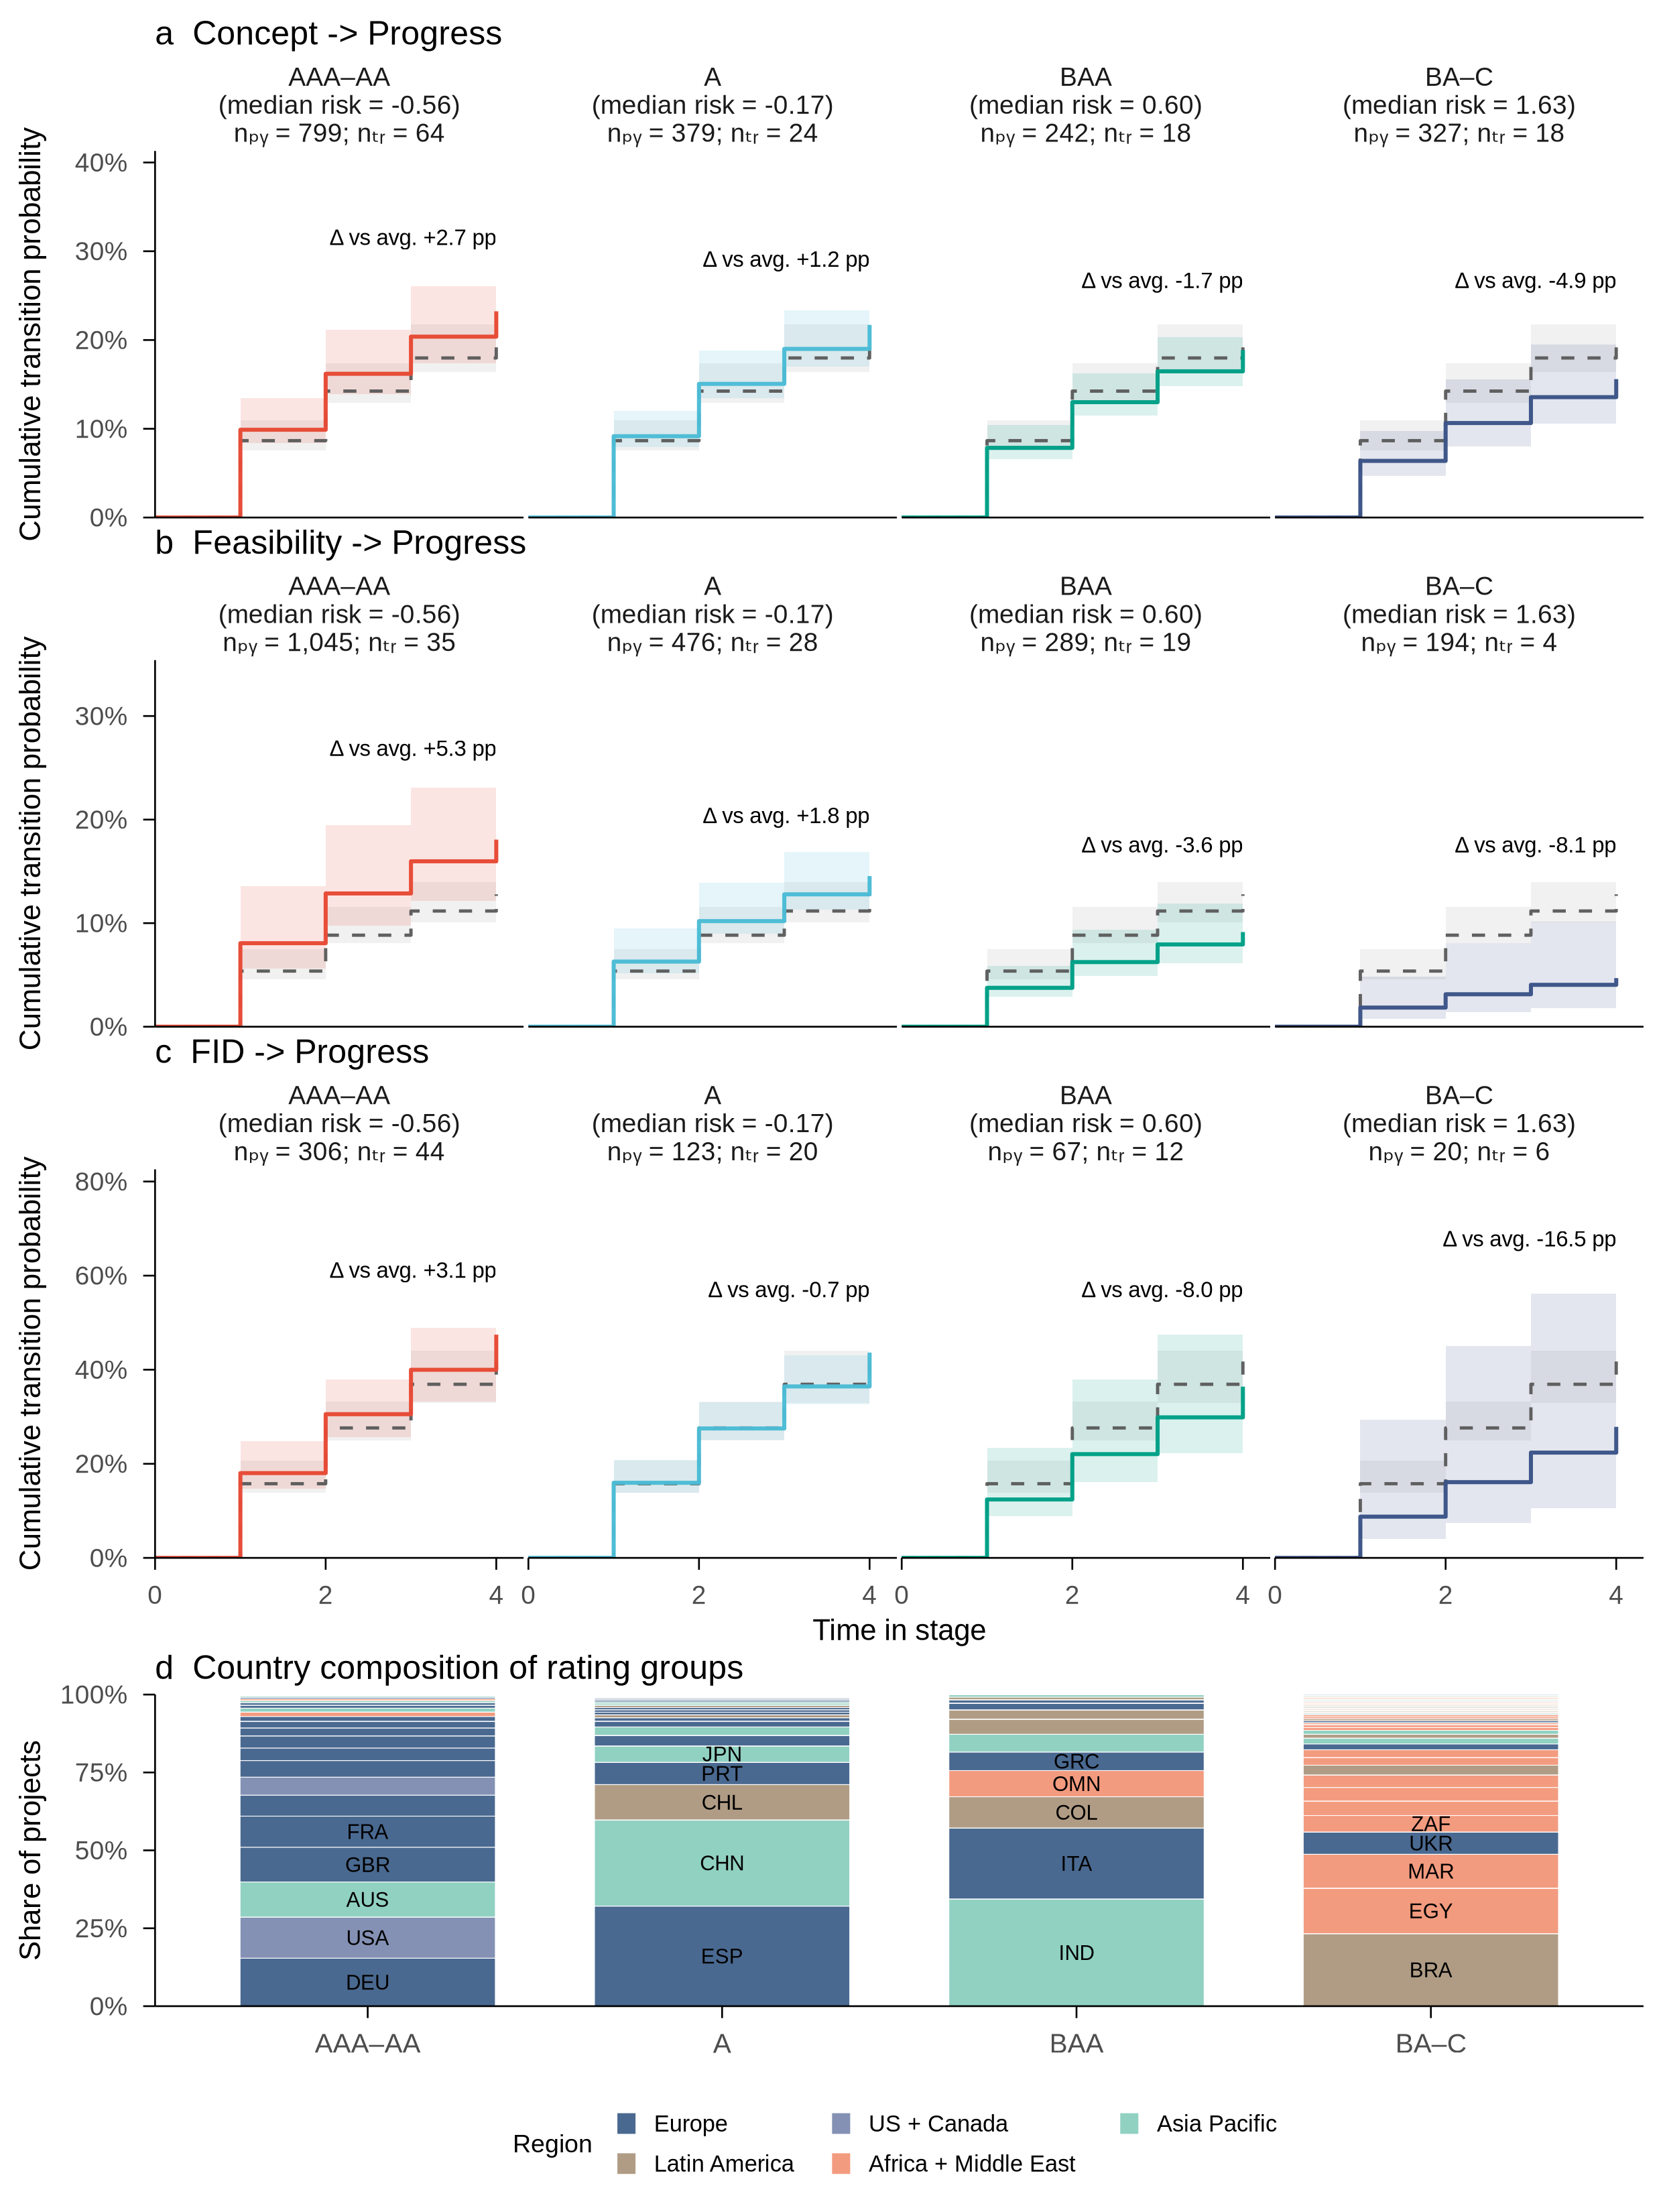

In [4]:
# ==============================================================================
# RATING-GROUP FIGURE
#
# Four aggregated rating groups:
#   1. AAA-AA
#   2. A
#   3. BAA
#   4. BA-C
#
# Figure-specific rating-group copies are constructed for the plotted aggregation.
# ==============================================================================


# ------------------------------------------------------------------------------
# Rating-group settings
# ------------------------------------------------------------------------------

transition_panel_labels <- c(
  "Concept -> Progress" = "a",
  "Feasibility -> Progress" = "b",
  "FID -> Progress" = "c"
)

time_var <- "prev_time_in_status"
raw_time_var <- "prev_time_in_status_raw"
risk_var <- "Country_Risk_Spread_log"
rating_group_var <- "rating_group"
region_var <- "region"

n_draws <- 300
conf_level <- 0.90

rating_group_levels <- c(
  "AAA-AA",
  "A",
  "BAA",
  "BA-C"
)

rating_group_labels <- c(
  "AAA-AA" = "AAA\u2013AA",
  "A" = "A",
  "BAA" = "BAA",
  "BA-C" = "BA\u2013C"
)


# ------------------------------------------------------------------------------
# Aggregate detailed rating categories
#
# The function is idempotent: it also recognises values that have already been
# aggregated using either a hyphen or an en dash.
# ------------------------------------------------------------------------------

aggregate_rating_group <- function(x) {
  x <- stringr::str_squish(
    as.character(x)
  )

  x <- stringr::str_to_upper(x)

  x <- stringr::str_replace_all(
    x,
    "[\u2013\u2014]",
    "-"
  )

  dplyr::case_when(
    x %in% c(
      "AAA",
      "AA",
      "AAA-AA"
    ) ~
      "AAA-AA",

    x == "A" ~
      "A",

    x == "BAA" ~
      "BAA",

    x %in% c(
      "BA",
      "B",
      "CAA",
      "CA",
      "C",
      "BA-C",
      "BA-CAA",
      "CAA-C",
      "CA-C"
    ) ~
      "BA-C",

    TRUE ~
      NA_character_
  )
}


cloglog_data_rating <- cloglog_data %>%
  dplyr::mutate(
    rating_group = aggregate_rating_group(
      .data[[rating_group_var]]
    )
  )


master_data_rating <- master_data %>%
  dplyr::mutate(
    rating_group = aggregate_rating_group(
      .data[[rating_group_var]]
    )
  )


# ------------------------------------------------------------------------------
# Validate rating-group variables
# ------------------------------------------------------------------------------

required_rating_group_vars <- c(
  "reference",
  risk_var,
  rating_group_var
)

missing_rating_group_vars <- setdiff(
  required_rating_group_vars,
  names(cloglog_data_rating)
)

if (length(missing_rating_group_vars) > 0) {
  stop(
    paste0(
      "Variables required to define the rating groups are missing from cloglog_data: ",
      paste(
        missing_rating_group_vars,
        collapse = ", "
      )
    )
  )
}


# ------------------------------------------------------------------------------
# Construct one rating-group observation per project
#
# Long project-period histories do not receive more weight when calculating the
# representative risk value of each rating group.
# ------------------------------------------------------------------------------

rating_reference_data <- cloglog_data_rating %>%
  dplyr::transmute(
    reference = reference,
    rating_group = stringr::str_squish(
      as.character(
        .data[[rating_group_var]]
      )
    ),
    country_risk = suppressWarnings(
      as.numeric(
        .data[[risk_var]]
      )
    )
  ) %>%
  dplyr::filter(
    !is.na(reference),
    !is.na(rating_group),
    rating_group %in% rating_group_levels,
    is.finite(country_risk)
  ) %>%
  dplyr::group_by(
    reference
  ) %>%
  dplyr::summarise(
    rating_group = first_non_missing_character(
      rating_group
    ),
    country_risk = stats::median(
      country_risk,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  dplyr::filter(
    !is.na(rating_group),
    rating_group %in% rating_group_levels,
    is.finite(country_risk)
  )


rating_group_profiles <- rating_reference_data %>%
  dplyr::group_by(
    rating_group
  ) %>%
  dplyr::summarise(
    risk_value = stats::median(
      country_risk,
      na.rm = TRUE
    ),
    risk_min = min(
      country_risk,
      na.rm = TRUE
    ),
    risk_max = max(
      country_risk,
      na.rm = TRUE
    ),
    n_projects = dplyr::n_distinct(
      reference
    ),
    .groups = "drop"
  )


missing_rating_groups <- setdiff(
  rating_group_levels,
  rating_group_profiles$rating_group
)

if (length(missing_rating_groups) > 0) {
  stop(
    paste0(
      "The following rating groups contain no projects: ",
      paste(
        missing_rating_groups,
        collapse = ", "
      )
    )
  )
}


rating_reference_data <- rating_reference_data %>%
  dplyr::mutate(
    rating_group = factor(
      rating_group,
      levels = rating_group_levels
    )
  )


rating_group_profiles <- rating_group_profiles %>%
  dplyr::mutate(
    rating_group = factor(
      rating_group,
      levels = rating_group_levels
    ),
    rating_group_label = factor(
      unname(
        rating_group_labels[
          as.character(rating_group)
        ]
      ),
      levels = unname(
        rating_group_labels[
          rating_group_levels
        ]
      )
    )
  ) %>%
  dplyr::arrange(
    rating_group
  )


rating_group_colours <- make_npg_palette(
  rating_group_levels
)


# ------------------------------------------------------------------------------
# Generate rating-group transition curves
#
# The prediction functions use the median continuous country-risk value of each
# plotted rating group.
# ------------------------------------------------------------------------------

curve_results <- purrr::map(
  transition_names,
  ~ make_transition_rating_group_and_average_curves(
    cloglog_results = cloglog_results_full,
    transition_name = .x,
    rating_profiles = rating_group_profiles,
    time_var = time_var,
    risk_var = risk_var,
    n_draws = n_draws,
    conf_level = conf_level
  )
)

names(curve_results) <- transition_names


rating_group_curve_data <- dplyr::bind_rows(
  purrr::map(
    curve_results,
    "rating_group_curves"
  )
)


average_curve_data <- dplyr::bind_rows(
  purrr::map(
    curve_results,
    "average_curve"
  )
)


if (nrow(rating_group_curve_data) == 0 ||
    nrow(average_curve_data) == 0) {
  stop(
    "No rating-group or average transition curves could be generated."
  )
}


# ------------------------------------------------------------------------------
# Count observed transitions by rating group
#
# Counts use the estimation sample of the selected full model and classify each
# observed event using the project-level plotted rating group.
# ------------------------------------------------------------------------------

make_transition_rating_group_counts <- function(
    transition_name,
    cloglog_results
) {
  model_obj <- cloglog_results$models[[transition_name]]

  if (is.null(model_obj)) {
    stop(
      paste0(
        "No fitted model was found for ",
        transition_name,
        "."
      )
    )
  }

  outcome_var <- dplyr::case_when(
    grepl(
      "Progress$",
      transition_name
    ) ~
      "progress",

    grepl(
      "Failure$",
      transition_name
    ) ~
      "failure",

    TRUE ~
      NA_character_
  )

  if (is.na(outcome_var)) {
    stop(
      paste0(
        "Could not identify the outcome variable for ",
        transition_name,
        "."
      )
    )
  }

  model_data <- model_obj$data

  missing_count_vars <- setdiff(
    c(
      "reference",
      outcome_var
    ),
    names(model_data)
  )

  if (length(missing_count_vars) > 0) {
    stop(
      paste0(
        "Variables required to count transitions are missing: ",
        paste(
          missing_count_vars,
          collapse = ", "
        )
      )
    )
  }

  observed_counts <- model_data %>%
    dplyr::transmute(
      reference = reference,
      transition_event = .data[[outcome_var]]
    ) %>%
    dplyr::left_join(
      rating_reference_data %>%
        dplyr::select(
          reference,
          rating_group
        ),
      by = "reference"
    ) %>%
    dplyr::filter(
      !is.na(rating_group)
    ) %>%
    dplyr::group_by(
      rating_group
    ) %>%
    dplyr::summarise(
      n_project_years = dplyr::n(),
      n_transitions = sum(
        transition_event == 1,
        na.rm = TRUE
      ),
      .groups = "drop"
    )

  tibble::tibble(
    rating_group = factor(
      rating_group_levels,
      levels = rating_group_levels
    )
  ) %>%
    dplyr::left_join(
      observed_counts,
      by = "rating_group"
    ) %>%
    dplyr::left_join(
      rating_group_profiles %>%
        dplyr::select(
          rating_group,
          rating_group_label,
          risk_value
        ),
      by = "rating_group"
    ) %>%
    dplyr::mutate(
      n_project_years = tidyr::replace_na(
        as.integer(n_project_years),
        0L
      ),
      n_transitions = tidyr::replace_na(
        as.integer(n_transitions),
        0L
      )
    )
}


# ------------------------------------------------------------------------------
# Plot rating-group curves against the sample-average curve
# ------------------------------------------------------------------------------

make_transition_rating_group_vs_average_plot <- function(
    transition_name,
    panel_label,
    show_x_axis = FALSE
) {
  plot_data <- make_rating_group_average_plot_data(
    transition_name = transition_name,
    rating_group_curve_data = rating_group_curve_data,
    average_curve_data = average_curve_data,
    rating_profiles = rating_group_profiles
  )

  transition_rating_group_counts <- make_transition_rating_group_counts(
    transition_name = transition_name,
    cloglog_results = cloglog_results_full
  )

  facet_title_labels <- stats::setNames(
    paste0(
      as.character(
        transition_rating_group_counts$rating_group_label
      ),
      "\n(median risk = ",
      scales::number(
        transition_rating_group_counts$risk_value,
        accuracy = 0.01
      ),
      ")\nnₚᵧ = ",
      scales::comma(
        transition_rating_group_counts$n_project_years,
        accuracy = 1
      ),
      "; nₜᵣ = ",
      scales::comma(
        transition_rating_group_counts$n_transitions,
        accuracy = 1
      )
    ),
    as.character(
      transition_rating_group_counts$rating_group_label
    )
  )

  row_y_values <- c(
    plot_data$risk_data$cumulative_transition_probability,
    plot_data$risk_data$conf_high,
    plot_data$average_data$cumulative_transition_probability,
    plot_data$average_data$conf_high,
    plot_data$label_data$label_y
  )

  row_y_values <- row_y_values[
    is.finite(row_y_values)
  ]

  row_y_upper <- if (length(row_y_values) == 0) {
    1
  } else {
    min(
      1,
      max(
        0.05,
        ceiling(
          max(row_y_values) / 0.05
        ) * 0.05
      )
    )
  }

  row_y_limits <- c(
    0,
    row_y_upper
  )

  risk_ribbon_data <- make_step_ribbon_data(
    data = plot_data$risk_data,
    group_vars = c(
      "transition",
      "rating_group",
      "rating_group_label"
    )
  )

  average_ribbon_data <- make_step_ribbon_data(
    data = plot_data$average_data,
    group_vars = c(
      "transition",
      "rating_group",
      "rating_group_label"
    )
  )

  p <- ggplot() +
    geom_ribbon(
      data = average_ribbon_data,
      aes(
        x = time,
        ymin = conf_low,
        ymax = conf_high,
        group = rating_group_label
      ),
      fill = "grey70",
      alpha = 0.18,
      colour = NA,
      show.legend = FALSE
    ) +
    geom_ribbon(
      data = risk_ribbon_data,
      aes(
        x = time,
        ymin = conf_low,
        ymax = conf_high,
        fill = rating_group,
        group = rating_group_label
      ),
      alpha = 0.14,
      colour = NA,
      show.legend = FALSE
    ) +
    geom_step(
      data = plot_data$average_data,
      aes(
        x = time,
        y = cumulative_transition_probability,
        group = rating_group_label
      ),
      colour = "grey35",
      linewidth = 0.55,
      alpha = 0.95,
      linetype = "dashed",
      direction = "hv",
      show.legend = FALSE
    ) +
    geom_step(
      data = plot_data$risk_data,
      aes(
        x = time,
        y = cumulative_transition_probability,
        colour = rating_group,
        group = rating_group_label
      ),
      linewidth = 0.68,
      alpha = 0.98,
      direction = "hv",
      show.legend = FALSE
    ) +
    geom_text(
      data = plot_data$label_data,
      aes(
        x = time,
        y = label_y,
        label = label
      ),
      inherit.aes = FALSE,
      hjust = 1,
      vjust = -0.25,
      size = 2.775,
      colour = "black"
    ) +
    facet_wrap(
      ~ rating_group_label,
      nrow = 1,
      scales = "fixed",
      labeller = ggplot2::as_labeller(
        facet_title_labels
      )
    ) +
    scale_colour_manual(
      values = rating_group_colours,
      breaks = rating_group_levels,
      drop = FALSE
    ) +
    scale_fill_manual(
      values = rating_group_colours,
      breaks = rating_group_levels,
      drop = FALSE
    ) +
    scale_x_continuous(
      breaks = scales::breaks_pretty(
        n = 3
      ),
      limits = c(
        0,
        NA
      ),
      expand = expansion(
        mult = c(
          0,
          0.08
        )
      )
    ) +
    scale_y_continuous(
      limits = row_y_limits,
      labels = scales::label_percent(
        accuracy = 1
      ),
      breaks = scales::breaks_pretty(
        n = 4
      ),
      expand = expansion(
        mult = c(
          0,
          0.18
        )
      )
    ) +
    labs(
      title = paste0(
        panel_label,
        "  ",
        transition_name
      ),
      x = if (show_x_axis) {
        "Time in stage"
      } else {
        NULL
      },
      y = "Cumulative transition probability"
    ) +
    base_theme +
    theme(
      legend.position = "none",
      plot.title = element_text(
        hjust = 0,
        size = 12,
        face = "plain",
        margin = margin(
          b = 2
        )
      ),
      axis.title.x = element_text(
        size = 10.5,
        margin = margin(
          t = 3
        )
      ),
      axis.title.y = element_text(
        size = 10.5,
        margin = margin(
          r = 3
        )
      ),
      axis.text.x = element_text(
        size = 9.3
      ),
      axis.text.y = element_text(
        size = 9.3
      ),
      strip.text = element_text(
        size = 9.3,
        margin = margin(
          t = 2,
          b = 2
        )
      ),
      panel.spacing.x = grid::unit(
        0.12,
        "lines"
      ),
      plot.margin = margin(
        2,
        2,
        2,
        2
      )
    )

  if (!show_x_axis) {
    p <- p +
      theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
      )
  }

  p
}


# ------------------------------------------------------------------------------
# Construct progression panels
# ------------------------------------------------------------------------------

p_concept_rating_group_average <- make_transition_rating_group_vs_average_plot(
  transition_name = "Concept -> Progress",
  panel_label = transition_panel_labels[["Concept -> Progress"]],
  show_x_axis = FALSE
)

p_feasibility_rating_group_average <- make_transition_rating_group_vs_average_plot(
  transition_name = "Feasibility -> Progress",
  panel_label = transition_panel_labels[["Feasibility -> Progress"]],
  show_x_axis = FALSE
)

p_fid_rating_group_average <- make_transition_rating_group_vs_average_plot(
  transition_name = "FID -> Progress",
  panel_label = transition_panel_labels[["FID -> Progress"]],
  show_x_axis = TRUE
)


p_rating_group_average_rows <-
  p_concept_rating_group_average /
  p_feasibility_rating_group_average /
  p_fid_rating_group_average +
  patchwork::plot_layout(
    heights = c(
      1,
      1,
      1.06
    )
  )


# ------------------------------------------------------------------------------
# Country composition of the rating groups
#
# The composition panel uses one project-level record from master_data.
# Countries are separate segments and are coloured by region using the ggsci
# D3 palette, selected to avoid the colours used for the rating-group curves.
# The five largest countries within each rating group are labelled.
# ------------------------------------------------------------------------------

required_master_rating_vars <- c(
  "reference",
  rating_group_var,
  "country",
  region_var
)

missing_master_rating_vars <- setdiff(
  required_master_rating_vars,
  names(master_data_rating)
)

if (length(missing_master_rating_vars) > 0) {
  stop(
    paste0(
      "Variables required for the rating-group composition panel are missing from master_data: ",
      paste(
        missing_master_rating_vars,
        collapse = ", "
      )
    )
  )
}


rating_composition_reference_data <- master_data_rating %>%
  dplyr::transmute(
    reference = reference,
    rating_group = stringr::str_squish(
      as.character(
        .data[[rating_group_var]]
      )
    ),
    country = stringr::str_squish(
      as.character(country)
    ),
    region = stringr::str_squish(
      as.character(
        .data[[region_var]]
      )
    )
  ) %>%
  dplyr::filter(
    !is.na(reference)
  ) %>%
  dplyr::group_by(
    reference
  ) %>%
  dplyr::summarise(
    rating_group = first_non_missing_character(
      rating_group
    ),
    country = first_non_missing_character(
      country
    ),
    region = first_non_missing_character(
      region
    ),
    .groups = "drop"
  ) %>%
  dplyr::filter(
    !is.na(rating_group),
    rating_group %in% rating_group_levels,
    !is.na(country),
    country != "",
    !stringr::str_to_lower(country) %in% c(
      "unassigned",
      "unknown",
      "other / unspecified"
    ),
    !is.na(region),
    region != "",
    !stringr::str_to_lower(region) %in% c(
      "unassigned",
      "unknown",
      "other / unspecified"
    )
  )


# Assign each country its modal region.
country_region_lookup <- rating_composition_reference_data %>%
  dplyr::count(
    country,
    region,
    name = "region_projects"
  ) %>%
  dplyr::group_by(
    country
  ) %>%
  dplyr::arrange(
    dplyr::desc(region_projects),
    match(
      region,
      region_order
    ),
    region,
    .by_group = TRUE
  ) %>%
  dplyr::slice_head(
    n = 1
  ) %>%
  dplyr::ungroup() %>%
  dplyr::select(
    country,
    region
  )


# Use total project counts only to obtain a consistent stacking order across
# the four bars.
country_totals <- rating_composition_reference_data %>%
  dplyr::count(
    country,
    name = "total_projects"
  ) %>%
  dplyr::arrange(
    dplyr::desc(total_projects),
    country
  )


available_composition_countries <- country_totals %>%
  dplyr::pull(
    country
  )

if (length(available_composition_countries) == 0) {
  stop(
    "No assigned countries are available for the rating-group composition panel."
  )
}


available_regions <- country_region_lookup %>%
  dplyr::distinct(
    region
  ) %>%
  dplyr::pull(
    region
  )

composition_region_levels <- c(
  intersect(
    region_order,
    available_regions
  ),
  sort(
    setdiff(
      available_regions,
      region_order
    )
  )
)

composition_region_colours <- c(
  "Europe" = "#4A6990FF",
  "US + Canada" = "#8491B4FF",
  "Asia Pacific" = "#91D1C2FF",
  "Latin America" = "#B09C85FF",
  "Africa + Middle East" = "#F39B7FFF" 
)

missing_region_colours <- setdiff(
  composition_region_levels,
  names(composition_region_colours)
)

if (length(missing_region_colours) > 0) {
  stop(
    paste0(
      "No deterministic colour has been assigned to: ",
      paste(
        missing_region_colours,
        collapse = ", "
      )
    )
  )
}

composition_region_colours <- composition_region_colours[
  composition_region_levels
]

rating_group_country_counts <- rating_composition_reference_data %>%
  dplyr::count(
    rating_group,
    country,
    name = "n_projects"
  )

# Identify exactly the five largest countries within each rating group.
# Alphabetical order resolves ties in project counts reproducibly.
top_5_countries_by_rating_group <- rating_group_country_counts %>%
  dplyr::filter(
    n_projects > 0
  ) %>%
  dplyr::group_by(
    rating_group
  ) %>%
  dplyr::arrange(
    dplyr::desc(n_projects),
    country,
    .by_group = TRUE
  ) %>%
  dplyr::mutate(
    country_rank = dplyr::row_number()
  ) %>%
  dplyr::filter(
    country_rank <= 5L
  ) %>%
  dplyr::ungroup() %>%
  dplyr::transmute(
    rating_group,
    country,
    country_label = country
  )


rating_group_country_composition <- tidyr::expand_grid(
  rating_group = rating_group_levels,
  country = available_composition_countries
) %>%
  dplyr::left_join(
    country_region_lookup,
    by = "country"
  ) %>%
  dplyr::left_join(
    rating_group_country_counts,
    by = c(
      "rating_group",
      "country"
    )
  ) %>%
  dplyr::left_join(
    top_5_countries_by_rating_group,
    by = c(
      "rating_group",
      "country"
    )
  ) %>%
  dplyr::mutate(
    n_projects = tidyr::replace_na(
      as.integer(n_projects),
      0L
    ),
    country_label = tidyr::replace_na(
      country_label,
      ""
    )
  ) %>%
  dplyr::group_by(
    rating_group
  ) %>%
  dplyr::mutate(
    share = n_projects / sum(
      n_projects
    )
  ) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(
    rating_group = factor(
      rating_group,
      levels = rating_group_levels
    ),
    country = factor(
      country,
      levels = rev(
        available_composition_countries
      )
    ),
    region = factor(
      region,
      levels = composition_region_levels
    )
  )


if (any(!is.finite(rating_group_country_composition$share))) {
  stop(
    "Each rating group must contain at least one project with an assigned country and region."
  )
}


p_rating_group_country_composition <- ggplot(
  rating_group_country_composition,
  aes(
    x = rating_group,
    y = share,
    fill = region,
    group = country
  )
) +
  geom_col(
    width = 0.72,
    colour = "white",
    linewidth = 0.12
  ) +
  geom_text(
    aes(
      label = country_label
    ),
    position = position_stack(
      vjust = 0.5
    ),
    size = 2.625,
    colour = "black"
  ) +
  scale_fill_manual(
    values = composition_region_colours,
    breaks = composition_region_levels,
    drop = FALSE
  ) +
  scale_x_discrete(
    labels = rating_group_labels,
    drop = FALSE
  ) +
  scale_y_continuous(
    limits = c(
      0,
      1
    ),
    labels = scales::label_percent(
      accuracy = 1
    ),
    breaks = seq(
      0,
      1,
      by = 0.25
    ),
    expand = expansion(
      mult = c(
        0,
        0
      )
    )
  ) +
  labs(
    title = "d  Country composition of rating groups",
    x = NULL,
    y = "Share of projects",
    fill = "Region"
  ) +
  base_theme +
  theme(
    plot.title = element_text(
      hjust = 0,
      size = 12,
      face = "plain",
      margin = margin(
        b = 2
      )
    ),
    axis.title.y = element_text(
      size = 10.5,
      margin = margin(
        r = 3
      )
    ),
    axis.text.x = element_text(
      size = 9.75
    ),
    axis.text.y = element_text(
      size = 9.3
    ),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box = "horizontal",
    legend.title = element_text(
      size = 9
    ),
    legend.text = element_text(
      size = 8.25
    ),
    legend.key.size = grid::unit(
      0.25,
      "cm"
    ),
    legend.spacing.x = grid::unit(
      0.08,
      "cm"
    ),
    plot.margin = margin(
      2,
      2,
      2,
      2
    )
  ) +
  guides(
    fill = guide_legend(
      nrow = max(
        1,
        ceiling(
          length(composition_region_levels) / 4
        )
      ),
      byrow = TRUE
    )
  )


# ------------------------------------------------------------------------------
# Figure composition and export
# ------------------------------------------------------------------------------


p_figure_rating_groups <-
  patchwork::wrap_plots(
    p_concept_rating_group_average,
    p_feasibility_rating_group_average,
    p_fid_rating_group_average,
    p_rating_group_country_composition,
    ncol = 1,
    heights = c(
      1,
      1,
      1.06,
      0.85
    )
  ) +
  patchwork::plot_annotation(
    theme = theme(
      plot.margin = margin(
        5,
        5,
        5,
        5
      )
    )
  )


figure_width_in <- 8.27
figure_height_in <- 11

options(
  repr.plot.width = figure_width_in,
  repr.plot.height = figure_height_in,
  repr.plot.res = 300
)


print(
  p_figure_rating_groups
)


ggsave(
  filename = "figure_country_risk.pdf",
  plot = p_figure_rating_groups,
  width = figure_width_in,
  height = figure_height_in,
  units = "in",
  device = cairo_pdf
)


## Supplementary Figure S5: Competing risk model Regions

These panels use the fitted discrete-time multinomial competing-risk model and show the cumulative incidence of progression while retaining failure as a competing event. `No transition`, `Progress` and `Failure` form one exhaustive annual outcome distribution, so probability coherence is enforced by the model itself. Simulation-based 90% confidence bands use the project-clustered multinomial covariance matrix.

Output: `figure_S5_competing_risk_regions.pdf` and matching source-data CSV. This section loads the saved multinomial models and does not re-estimate the primary cloglog models.


Warning message:
“package ‘nnet’ was built under R version 4.5.3”


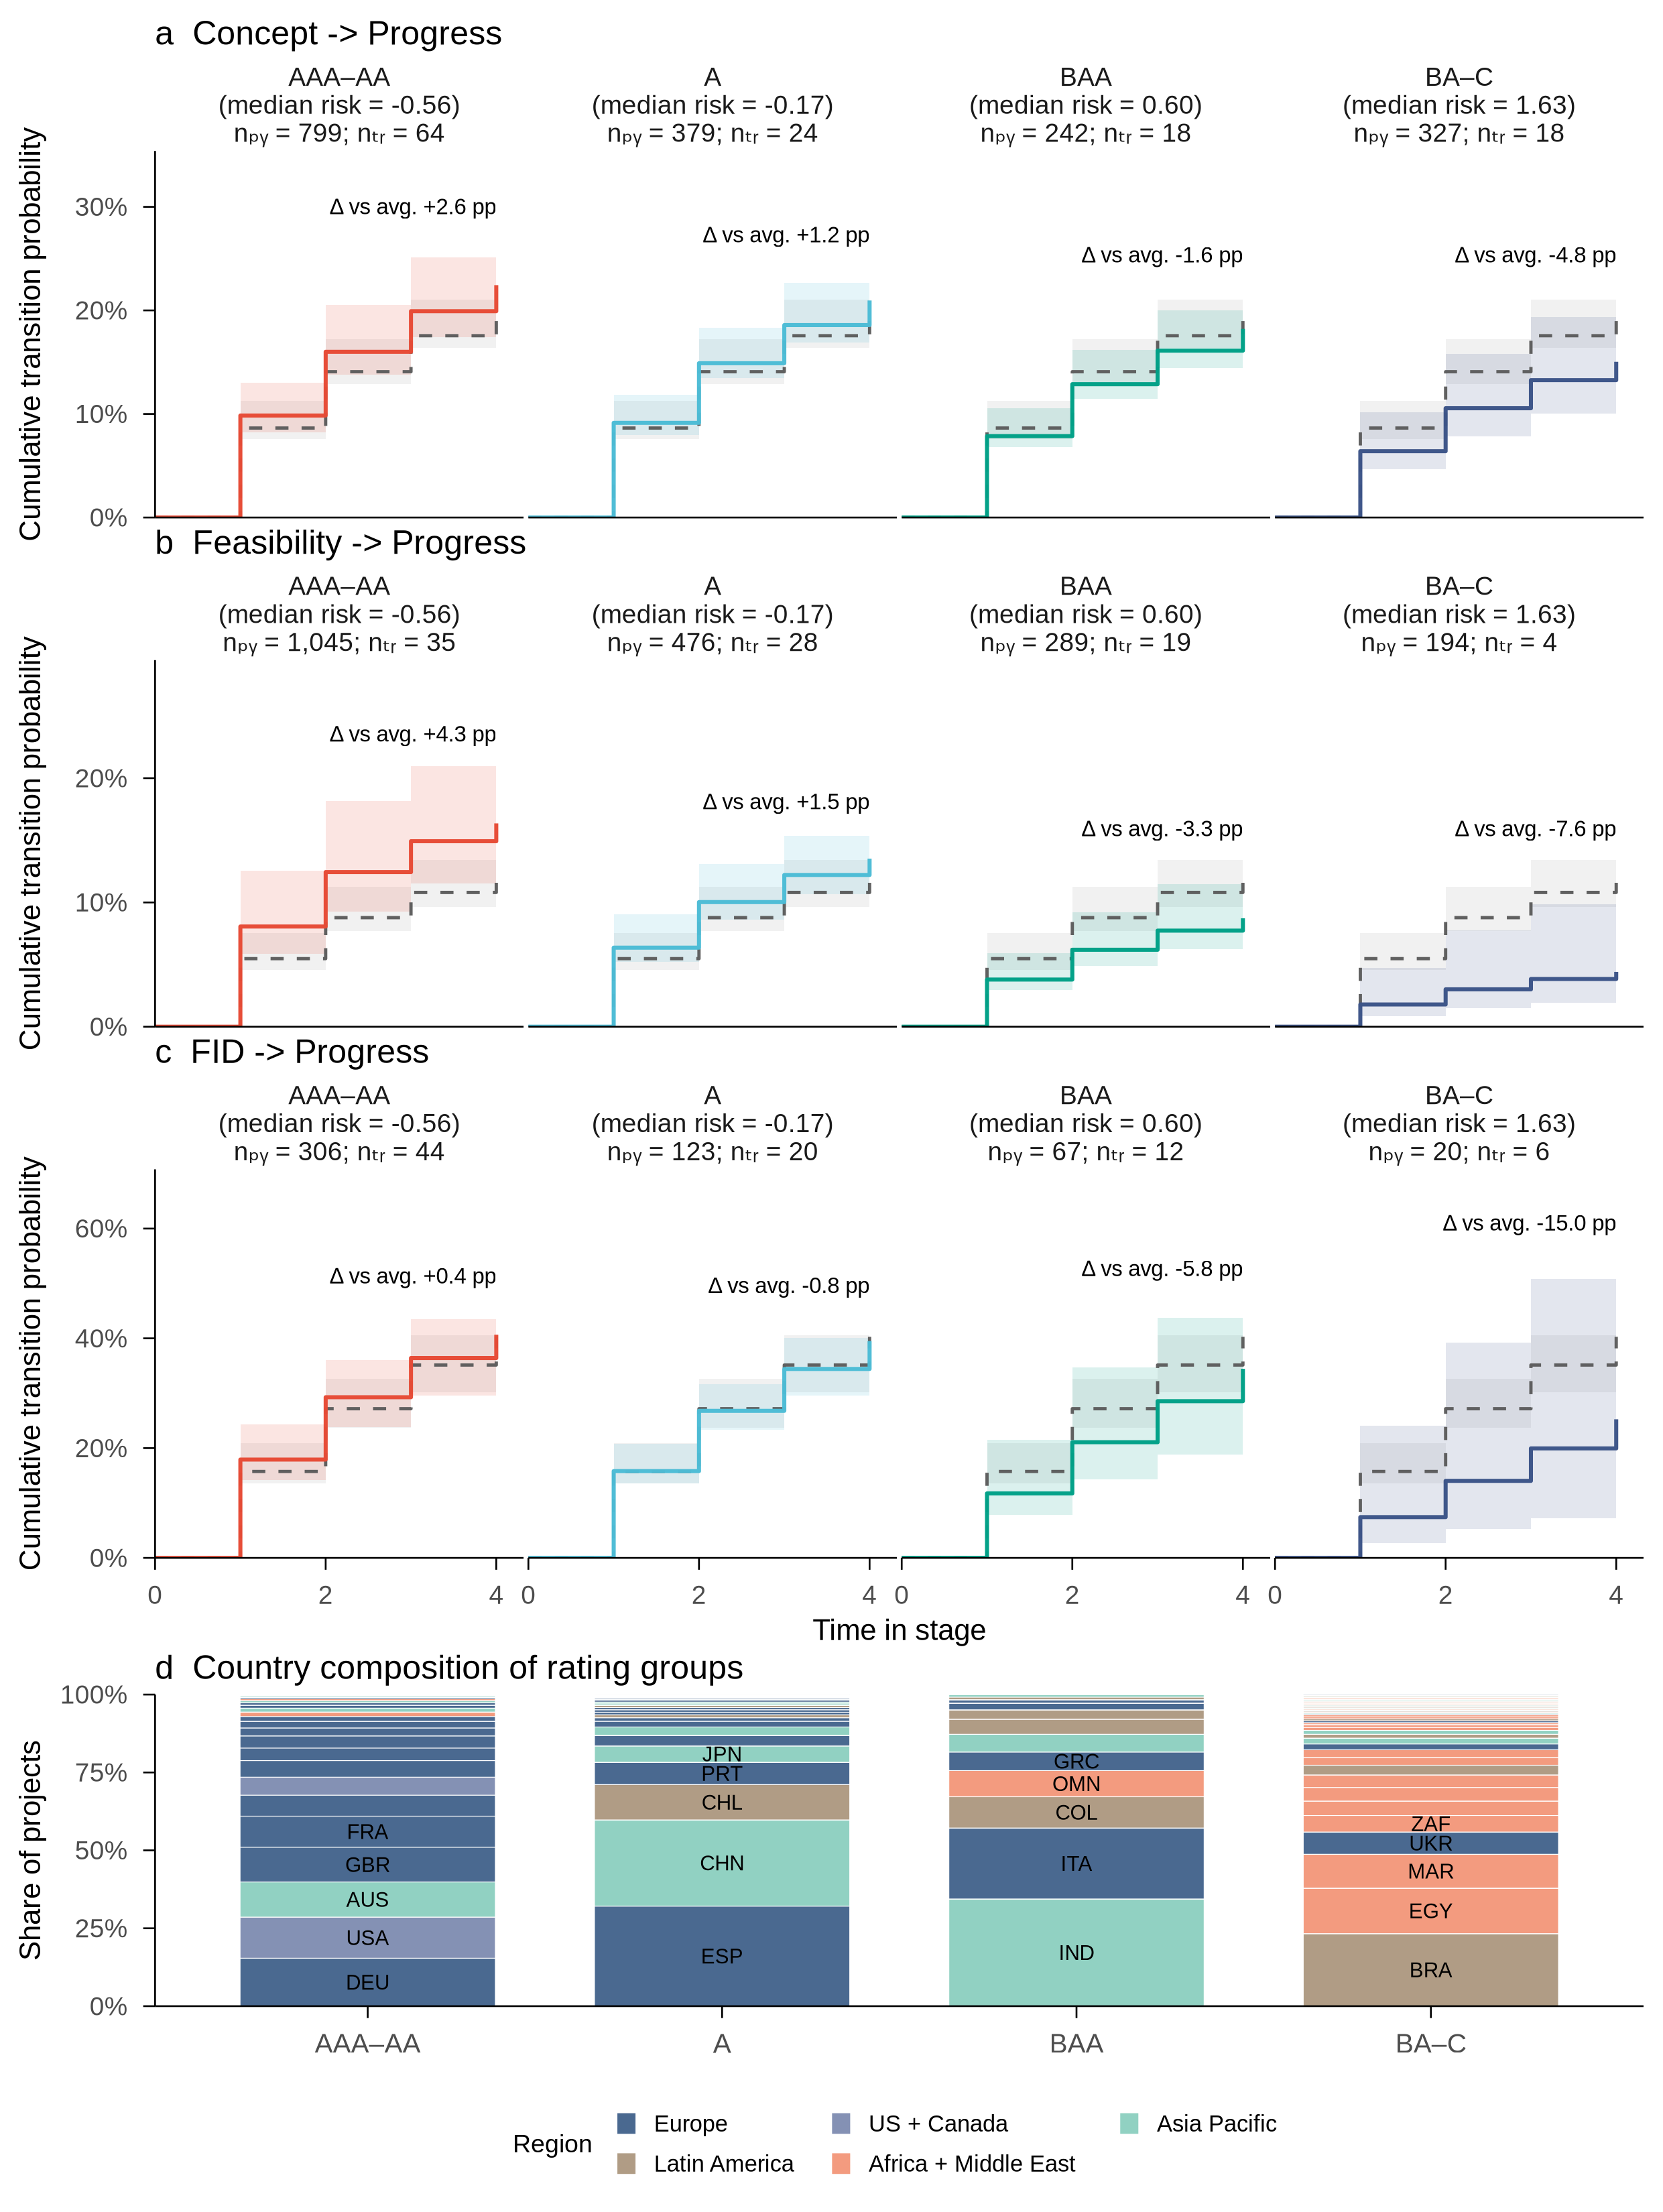

In [5]:
# ==============================================================================
# Packages and multinomial competing-risk inputs
# ==============================================================================

required_packages <- c(
  "dplyr",
  "tidyr",
  "purrr",
  "sandwich",
  "ggplot2",
  "ggsci",
  "scales",
  "patchwork",
  "nnet",
  "MASS",
  "stringr",
  "tibble"
)

missing_packages <- required_packages[
  !vapply(
    required_packages,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]

if (length(missing_packages) > 0) {
  stop(
    paste0(
      "Missing packages: ",
      paste(missing_packages, collapse = ", "),
      ". Install them before running this notebook."
    )
  )
}

invisible(
  lapply(
    required_packages,
    library,
    character.only = TRUE
  )
)

set.seed(123)


# ------------------------------------------------------------------------------
# Load the project-level data and the shared competing-risk model data
# ------------------------------------------------------------------------------

master_data_file <- "master_data.rds"
model_data_file <- "cloglog_data_processed.rds"

for (required_file in c(master_data_file, model_data_file)) {
  if (!file.exists(required_file)) {
    stop(
      paste0(
        "The required input file '",
        required_file,
        "' was not found. Run Data Preparation before this notebook."
      )
    )
  }
}

master_data <- readRDS(master_data_file)
cloglog_data <- readRDS(model_data_file)

# ------------------------------------------------------------------------------
# Load the fitted multinomial competing-risk models
# ------------------------------------------------------------------------------

model_results_file <- "multinomial_competing_risk_results.rds"

if (!file.exists(model_results_file)) {
  stop(
    paste0(
      "The multinomial competing-risk model-results file '",
      model_results_file,
      "' was not found. Run Discrete-Time-Multinomial-Competing-Risk-Model.ipynb before constructing these figures."
    )
  )
}

joint_competing_results <- readRDS(model_results_file)
assert_joint_model_variables <- function(model, required, context) {
  variables <- all.vars(stats::delete.response(stats::terms(model)))
  missing <- setdiff(required, variables)
  if (length(missing) > 0L) {
    stop(paste0(context, " is missing required multinomial-model predictors: ",
                paste(missing, collapse = ", ")))
  }
  invisible(TRUE)
}


transition_names <- c(
  "Concept -> Progress",
  "Feasibility -> Progress",
  "FID -> Progress"
)

full_model_name <- "Core + macro controls + year FE"

extract_joint_models <- function(
    results,
    transitions,
    model_name
) {
  extracted_models <- lapply(
    transitions,
    function(transition_name) {
      transition_models <- results$models[[transition_name]]

      if (is.null(transition_models)) {
        stop(
          paste0(
            "Transition '",
            transition_name,
            "' was not found in ",
            model_results_file,
            "."
          )
        )
      }

      model_obj <- transition_models[[model_name]]

      if (is.null(model_obj) || is.null(model_obj$model)) {
        stop(
          paste0(
            "Model '",
            model_name,
            "' was not available for ",
            transition_name,
            "."
          )
        )
      }

      model_obj
    }
  )

  names(extracted_models) <- transitions

  list(
    models = extracted_models
  )
}

joint_results_full <- extract_joint_models(
  results = joint_competing_results,
  transitions = transition_names,
  model_name = full_model_name
)


# ------------------------------------------------------------------------------
# Preferred regional display order
#
# The display order lists supported region categories. Categories absent from
# the data are omitted from the figure.
# ------------------------------------------------------------------------------

region_order <- c(
  "Europe",
  "US + Canada",
  "Asia Pacific",
  "Latin America",
  "Africa + Middle East"
)


# ------------------------------------------------------------------------------
# Shared plotting and prediction helpers
# ------------------------------------------------------------------------------

first_non_missing_character <- function(x) {
  x <- stringr::str_squish(
    as.character(x)
  )

  x <- x[
    !is.na(x) &
      x != ""
  ]

  if (length(x) == 0) {
    return(NA_character_)
  }

  x[[1]]
}


make_npg_palette <- function(levels) {
  levels <- as.character(levels)
  levels <- levels[
    !is.na(levels) &
      levels != ""
  ]

  if (length(levels) == 0) {
    return(
      stats::setNames(
        character(0),
        character(0)
      )
    )
  }

  base_colours <- ggsci::pal_npg()(10)

  selected_colours <- if (
    length(levels) <= length(base_colours)
  ) {
    base_colours[seq_along(levels)]
  } else {
    grDevices::colorRampPalette(base_colours)(
      length(levels)
    )
  }

  stats::setNames(
    selected_colours,
    levels
  )
}


base_theme <- theme_minimal(
  base_size = 12.75
) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.line.y.left = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.x = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.y = element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.length = grid::unit(
      1.5,
      "mm"
    ),
    plot.title = element_text(
      hjust = 0,
      face = "plain",
      size = 14.25,
      margin = margin(b = 4)
    ),
    axis.text = element_text(
      size = 11.25
    ),
    axis.title = element_text(
      size = 12
    ),
    strip.text = element_text(
      size = 11.25,
      face = "plain",
      margin = margin(b = 2)
    ),
    plot.margin = margin(
      5,
      5,
      5,
      5
    )
  )


make_psd <- function(x) {
  x <- (x + t(x)) / 2
  x[!is.finite(x)] <- 0

  eig <- eigen(x, symmetric = TRUE)
  eig$values <- pmax(eig$values, .Machine$double.eps)

  eig$vectors %*%
    diag(eig$values, nrow = length(eig$values)) %*%
    t(eig$vectors)
}

make_coef_draws <- function(
    model,
    model_data,
    n_draws = 300
) {
  beta_hat <- model$multinomial_coef_vector
  vcov_mat <- model$cluster_vcov

  if (is.null(beta_hat) || is.null(vcov_mat)) {
    stop("The saved multinomial model does not contain clustered inference objects.")
  }

  if (any(!is.finite(beta_hat)) ||
      any(!is.finite(vcov_mat)) ||
      any(diag(vcov_mat) < 0)) {
    stop("The multinomial coefficient vector or clustered covariance is non-finite.")
  }

  draws <- MASS::mvrnorm(
    n = n_draws,
    mu = beta_hat,
    Sigma = make_psd(vcov_mat)
  )

  draws <- as.matrix(draws)
  colnames(draws) <- names(beta_hat)
  draws
}

make_multinomial_prediction_matrix <- function(model, pred_data) {
  terms_no_response <- stats::delete.response(stats::terms(model))

  model_frame <- stats::model.frame(
    terms_no_response,
    data = pred_data,
    xlev = model$xlevels,
    na.action = stats::na.pass,
    drop.unused.levels = FALSE
  )

  x_mat <- stats::model.matrix(
    terms_no_response,
    data = model_frame,
    contrasts.arg = model$contrasts
  )

  target_terms <- colnames(model$multinomial_coef_matrix)
  missing_terms <- setdiff(target_terms, colnames(x_mat))

  if (length(missing_terms) > 0) {
    missing_mat <- matrix(
      0,
      nrow = nrow(x_mat),
      ncol = length(missing_terms)
    )
    colnames(missing_mat) <- missing_terms
    x_mat <- cbind(x_mat, missing_mat)
  }

  x_mat[, target_terms, drop = FALSE]
}

stable_multinomial_probabilities <- function(eta_progress, eta_failure) {
  max_eta <- pmax(0, eta_progress, eta_failure)
  denominator <- exp(-max_eta) +
    exp(eta_progress - max_eta) +
    exp(eta_failure - max_eta)

  list(
    no_transition = exp(-max_eta) / denominator,
    progress = exp(eta_progress - max_eta) / denominator,
    failure = exp(eta_failure - max_eta) / denominator
  )
}

predict_multinomial_competing_draws <- function(
    model,
    pred_data,
    coef_draws
) {
  x_mat <- make_multinomial_prediction_matrix(model, pred_data)
  coef_matrix <- model$multinomial_coef_matrix

  required_classes <- c("Progress", "Failure")
  if (!all(required_classes %in% rownames(coef_matrix))) {
    stop("The multinomial model is missing Progress or Failure coefficients.")
  }

  eta_progress_hat <- drop(x_mat %*% coef_matrix["Progress", ])
  eta_failure_hat <- drop(x_mat %*% coef_matrix["Failure", ])

  point_probs <- stable_multinomial_probabilities(
    eta_progress_hat,
    eta_failure_hat
  )

  progress_names <- paste0("Progress::", colnames(coef_matrix))
  failure_names <- paste0("Failure::", colnames(coef_matrix))

  if (!all(c(progress_names, failure_names) %in% colnames(coef_draws))) {
    stop("The coefficient draws do not align with the multinomial design matrix.")
  }

  eta_progress_draws <- x_mat %*%
    t(coef_draws[, progress_names, drop = FALSE])
  eta_failure_draws <- x_mat %*%
    t(coef_draws[, failure_names, drop = FALSE])

  draw_probs <- stable_multinomial_probabilities(
    eta_progress_draws,
    eta_failure_draws
  )

  list(
    no_transition_hat = as.numeric(point_probs$no_transition),
    progress_hat = as.numeric(point_probs$progress),
    failure_hat = as.numeric(point_probs$failure),
    no_transition_draws = as.matrix(draw_probs$no_transition),
    progress_draws = as.matrix(draw_probs$progress),
    failure_draws = as.matrix(draw_probs$failure)
  )
}

make_standardised_multinomial_curve <- function(
    model,
    pred_base,
    time_grid,
    time_scale,
    coef_draws,
    time_var = "prev_time_in_status",
    raw_time_var = "prev_time_in_status_raw",
    conf_level = 0.90
) {
  if (nrow(pred_base) == 0) {
    return(NULL)
  }

  alpha <- 1 - conf_level
  number_of_draws <- nrow(coef_draws)

  survival_hat <- rep(1, nrow(pred_base))
  progression_cif_hat <- rep(0, nrow(pred_base))

  survival_draws <- matrix(
    1,
    nrow = nrow(pred_base),
    ncol = number_of_draws
  )
  progression_cif_draws <- matrix(
    0,
    nrow = nrow(pred_base),
    ncol = number_of_draws
  )

  annual_hazard <- numeric(length(time_grid))
  cumulative_hat <- numeric(length(time_grid))
  cumulative_draw_mat <- matrix(
    NA_real_,
    nrow = length(time_grid),
    ncol = number_of_draws
  )

  for (i in seq_along(time_grid)) {
    pred_data <- pred_base
    pred_data[[raw_time_var]] <- time_grid[i]
    pred_data[[time_var]] <- apply_time_scale(
      time_raw = time_grid[i],
      time_scale = time_scale
    )

    pred <- predict_multinomial_competing_draws(
      model = model,
      pred_data = pred_data,
      coef_draws = coef_draws
    )

    point_sum <- pred$no_transition_hat +
      pred$progress_hat +
      pred$failure_hat

    if (any(!is.finite(point_sum)) ||
        any(abs(point_sum - 1) > 1e-8)) {
      stop(
        paste0(
          "Multinomial outcome probabilities are not coherent at duration ",
          time_grid[i],
          "."
        )
      )
    }

    progression_cif_hat <- progression_cif_hat +
      survival_hat * pred$progress_hat
    survival_hat <- survival_hat * pred$no_transition_hat

    progression_cif_draws <- progression_cif_draws +
      survival_draws * pred$progress_draws
    survival_draws <- survival_draws * pred$no_transition_draws

    annual_hazard[i] <- mean(pred$progress_hat, na.rm = TRUE)
    cumulative_hat[i] <- mean(progression_cif_hat, na.rm = TRUE)
    cumulative_draw_mat[i, ] <- colMeans(
      progression_cif_draws,
      na.rm = TRUE
    )
  }

  ci_mat <- t(
    apply(
      cumulative_draw_mat,
      1,
      stats::quantile,
      probs = c(alpha / 2, 1 - alpha / 2),
      na.rm = TRUE
    )
  )

  dplyr::bind_rows(
    tibble::tibble(
      time = 0,
      annual_hazard = NA_real_,
      cumulative_transition_probability = 0,
      conf_low = 0,
      conf_high = 0,
      valid_multinomial_draws = number_of_draws
    ),
    tibble::tibble(
      time = time_grid,
      annual_hazard = annual_hazard,
      cumulative_transition_probability = cumulative_hat,
      conf_low = ci_mat[, 1],
      conf_high = ci_mat[, 2],
      valid_multinomial_draws = number_of_draws
    )
  )
}


make_time_grid <- function(
    model_data,
    time_var,
    raw_time_var = "prev_time_in_status_raw"
) {
  if (!all(c(time_var, raw_time_var) %in% names(model_data))) {
    stop(
      paste0(
        "The fitted model data must contain both '",
        time_var,
        "' and '",
        raw_time_var,
        "'. Re-run Data Preparation and multinomial competing-risk."
      )
    )
  }

  max_time <- max(
    model_data[[raw_time_var]],
    na.rm = TRUE
  )

  if (!is.finite(max_time) || max_time < 1) {
    return(NULL)
  }

  seq(
    from = 1,
    to = ceiling(max_time),
    by = 1
  )
}


get_time_scale <- function(
    model_data,
    time_var,
    raw_time_var = "prev_time_in_status_raw"
) {
  time_mapping <- model_data %>%
    dplyr::transmute(
      time_model = as.numeric(.data[[time_var]]),
      time_raw = as.numeric(.data[[raw_time_var]])
    ) %>%
    dplyr::filter(
      is.finite(time_model),
      is.finite(time_raw)
    ) %>%
    dplyr::distinct()

  if (dplyr::n_distinct(time_mapping$time_raw) < 2) {
    stop(
      "At least two raw duration values are required to recover the model scale."
    )
  }

  mapping_model <- stats::lm(
    time_model ~ time_raw,
    data = time_mapping
  )

  c(
    intercept = unname(stats::coef(mapping_model)[[1]]),
    slope = unname(stats::coef(mapping_model)[[2]])
  )
}


apply_time_scale <- function(
    time_raw,
    time_scale
) {
  unname(
    time_scale[["intercept"]] +
      time_scale[["slope"]] * time_raw
  )
}


make_step_ribbon_data <- function(
    data,
    group_vars
) {
  if (nrow(data) == 0) {
    return(data)
  }

  value_cols <- c(
    "annual_hazard",
    "cumulative_transition_probability",
    "conf_low",
    "conf_high"
  )

  data %>%
    dplyr::arrange(
      dplyr::across(
        dplyr::all_of(
          c(
            group_vars,
            "time"
          )
        )
      )
    ) %>%
    dplyr::group_by(
      dplyr::across(
        dplyr::all_of(group_vars)
      )
    ) %>%
    dplyr::group_modify(
      function(.x, .y) {
        .x <- .x %>%
          dplyr::arrange(time)

        if (nrow(.x) <= 1) {
          return(.x)
        }

        out <- .x[1, , drop = FALSE]

        for (i in 2:nrow(.x)) {
          previous_row <- .x[i - 1, , drop = FALSE]
          current_row <- .x[i, , drop = FALSE]
          step_row <- current_row
          step_row[value_cols] <- previous_row[value_cols]

          out <- dplyr::bind_rows(
            out,
            step_row,
            current_row
          )
        }

        out
      }
    ) %>%
    dplyr::ungroup()
}


make_transition_rating_group_and_average_curves <- function(
    cloglog_results,
    transition_name,
    rating_profiles,
    time_var = "prev_time_in_status",
    risk_var = "Country_Risk_Spread_log",
    n_draws = 300,
    conf_level = 0.90
) {
  model_obj <- cloglog_results$models[[transition_name]]

  if (is.null(model_obj)) {
    return(NULL)
  }

  model <- model_obj$model
  model_data <- model_obj$data

  model_terms <- all.vars(stats::delete.response(stats::terms(model)))
  assert_joint_model_variables(model, c(time_var, risk_var), transition_name)

  if (!risk_var %in% names(model_data) ||
      !risk_var %in% model_terms) {
    stop(
      paste0(
        "The fitted model for ",
        transition_name,
        " does not contain '",
        risk_var,
        "'."
      )
    )
  }

  time_grid <- make_time_grid(
    model_data = model_data,
    time_var = time_var
  )

  if (is.null(time_grid)) {
    return(NULL)
  }

  time_scale <- get_time_scale(
    model_data = model_data,
    time_var = time_var,
    raw_time_var = raw_time_var
  )

  coef_draws <- make_coef_draws(
    model = model,
    model_data = model_data,
    n_draws = n_draws
  )

  make_curve <- function(pred_base) {
    make_standardised_multinomial_curve(
      model = model,
      pred_base = pred_base,
      time_grid = time_grid,
      time_scale = time_scale,
      coef_draws = coef_draws,
      time_var = time_var,
      raw_time_var = raw_time_var,
      conf_level = conf_level
    )
  }

  average_curve <- make_curve(
    model_data
  ) %>%
    dplyr::mutate(
      transition = transition_name,
      curve_type = "Sample average"
    )

  rating_group_curves <- purrr::pmap_dfr(
    list(
      as.character(rating_profiles$rating_group),
      as.character(rating_profiles$rating_group_label),
      rating_profiles$risk_value
    ),
    function(rating_group, rating_group_label, risk_value) {
      pred_base <- model_data
      pred_base[[risk_var]] <- rep(
        risk_value,
        nrow(pred_base)
      )

      make_curve(pred_base) %>%
        dplyr::mutate(
          transition = transition_name,
          rating_group = rating_group,
          rating_group_label = rating_group_label,
          risk_value = risk_value,
          curve_type = "Rating-group"
        )
    }
  ) %>%
    dplyr::mutate(
      rating_group = factor(
        rating_group,
        levels = rating_group_levels
      ),
      rating_group_label = factor(
        rating_group_label,
        levels = unname(
          rating_group_labels[rating_group_levels]
        )
      )
    )

  list(
    rating_group_curves = rating_group_curves,
    average_curve = average_curve
  )
}


make_rating_group_average_plot_data <- function(
    transition_name,
    rating_group_curve_data,
    average_curve_data,
    rating_profiles
) {
  transition_risk_data <- rating_group_curve_data %>%
    dplyr::filter(
      transition == transition_name
    )

  transition_average_data <- average_curve_data %>%
    dplyr::filter(
      transition == transition_name
    )

  average_expanded <- purrr::pmap_dfr(
    list(
      as.character(rating_profiles$rating_group),
      as.character(rating_profiles$rating_group_label),
      rating_profiles$risk_value
    ),
    function(rating_group, rating_group_label, risk_value) {
      transition_average_data %>%
        dplyr::mutate(
          rating_group = rating_group,
          rating_group_label = rating_group_label,
          risk_value = risk_value
        )
    }
  ) %>%
    dplyr::mutate(
      rating_group = factor(
        rating_group,
        levels = rating_group_levels
      ),
      rating_group_label = factor(
        rating_group_label,
        levels = unname(
          rating_group_labels[rating_group_levels]
        )
      )
    )

  risk_final <- transition_risk_data %>%
    dplyr::group_by(
      rating_group,
      rating_group_label
    ) %>%
    dplyr::slice_max(
      time,
      n = 1,
      with_ties = FALSE
    ) %>%
    dplyr::ungroup() %>%
    dplyr::select(
      rating_group,
      rating_group_label,
      time,
      risk_probability = cumulative_transition_probability,
      risk_conf_high = conf_high
    )

  average_final <- transition_average_data %>%
    dplyr::slice_max(
      time,
      n = 1,
      with_ties = FALSE
    ) %>%
    dplyr::transmute(
      average_probability = cumulative_transition_probability,
      average_conf_high = conf_high
    )

  label_data <- risk_final %>%
    dplyr::mutate(
      average_probability = average_final$average_probability[[1]],
      average_conf_high = average_final$average_conf_high[[1]],
      difference_pp = 100 * (
        risk_probability - average_probability
      ),
      label = paste0(
        "Δ vs avg. ",
        sprintf(
          "%+.1f",
          difference_pp
        ),
        " pp"
      ),
      label_y = pmax(
        risk_probability,
        average_probability,
        risk_conf_high,
        average_conf_high,
        na.rm = TRUE
      )
    )

  list(
    risk_data = transition_risk_data,
    average_data = average_expanded,
    label_data = label_data
  )
}


# ==============================================================================
# SUPPLEMENTARY COMPETING-RISK RATING-GROUP FIGURE
#
# Four aggregated rating groups:
#   1. AAA-AA
#   2. A
#   3. BAA
#   4. BA-C
#
# Figure-specific rating-group copies are constructed for the plotted aggregation.
# ==============================================================================


# ------------------------------------------------------------------------------
# Rating-group settings
# ------------------------------------------------------------------------------

transition_panel_labels <- c(
  "Concept -> Progress" = "a",
  "Feasibility -> Progress" = "b",
  "FID -> Progress" = "c"
)

time_var <- "prev_time_in_status"
raw_time_var <- "prev_time_in_status_raw"
risk_var <- "Country_Risk_Spread_log"
rating_group_var <- "rating_group"
region_var <- "region"

n_draws <- 300
conf_level <- 0.90

rating_group_levels <- c(
  "AAA-AA",
  "A",
  "BAA",
  "BA-C"
)

rating_group_labels <- c(
  "AAA-AA" = "AAA\u2013AA",
  "A" = "A",
  "BAA" = "BAA",
  "BA-C" = "BA\u2013C"
)


# ------------------------------------------------------------------------------
# Aggregate detailed rating categories
#
# The function is idempotent: it also recognises values that have already been
# aggregated using either a hyphen or an en dash.
# ------------------------------------------------------------------------------

aggregate_rating_group <- function(x) {
  x <- stringr::str_squish(
    as.character(x)
  )

  x <- stringr::str_to_upper(x)

  x <- stringr::str_replace_all(
    x,
    "[\u2013\u2014]",
    "-"
  )

  dplyr::case_when(
    x %in% c(
      "AAA",
      "AA",
      "AAA-AA"
    ) ~
      "AAA-AA",

    x == "A" ~
      "A",

    x == "BAA" ~
      "BAA",

    x %in% c(
      "BA",
      "B",
      "CAA",
      "CA",
      "C",
      "BA-C",
      "BA-CAA"
    ) ~
      "BA-C",

    TRUE ~
      NA_character_
  )
}


cloglog_data_rating <- cloglog_data %>%
  dplyr::mutate(
    rating_group = aggregate_rating_group(
      .data[[rating_group_var]]
    )
  )


master_data_rating <- master_data %>%
  dplyr::mutate(
    rating_group = aggregate_rating_group(
      .data[[rating_group_var]]
    )
  )


# ------------------------------------------------------------------------------
# Validate rating-group variables
# ------------------------------------------------------------------------------

required_rating_group_vars <- c(
  "reference",
  risk_var,
  rating_group_var
)

missing_rating_group_vars <- setdiff(
  required_rating_group_vars,
  names(cloglog_data_rating)
)

if (length(missing_rating_group_vars) > 0) {
  stop(
    paste0(
      "Variables required to define the rating groups are missing from cloglog_data: ",
      paste(
        missing_rating_group_vars,
        collapse = ", "
      )
    )
  )
}


# ------------------------------------------------------------------------------
# Construct one rating-group observation per project
#
# Long project-period histories do not receive more weight when calculating the
# representative risk value of each rating group.
# ------------------------------------------------------------------------------

rating_reference_data <- cloglog_data_rating %>%
  dplyr::transmute(
    reference = reference,
    rating_group = stringr::str_squish(
      as.character(
        .data[[rating_group_var]]
      )
    ),
    country_risk = suppressWarnings(
      as.numeric(
        .data[[risk_var]]
      )
    )
  ) %>%
  dplyr::filter(
    !is.na(reference),
    !is.na(rating_group),
    rating_group %in% rating_group_levels,
    is.finite(country_risk)
  ) %>%
  dplyr::group_by(
    reference
  ) %>%
  dplyr::summarise(
    rating_group = first_non_missing_character(
      rating_group
    ),
    country_risk = stats::median(
      country_risk,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  dplyr::filter(
    !is.na(rating_group),
    rating_group %in% rating_group_levels,
    is.finite(country_risk)
  )


rating_group_profiles <- rating_reference_data %>%
  dplyr::group_by(
    rating_group
  ) %>%
  dplyr::summarise(
    risk_value = stats::median(
      country_risk,
      na.rm = TRUE
    ),
    risk_min = min(
      country_risk,
      na.rm = TRUE
    ),
    risk_max = max(
      country_risk,
      na.rm = TRUE
    ),
    n_projects = dplyr::n_distinct(
      reference
    ),
    .groups = "drop"
  )


missing_rating_groups <- setdiff(
  rating_group_levels,
  rating_group_profiles$rating_group
)

if (length(missing_rating_groups) > 0) {
  stop(
    paste0(
      "The following rating groups contain no projects: ",
      paste(
        missing_rating_groups,
        collapse = ", "
      )
    )
  )
}


rating_reference_data <- rating_reference_data %>%
  dplyr::mutate(
    rating_group = factor(
      rating_group,
      levels = rating_group_levels
    )
  )


rating_group_profiles <- rating_group_profiles %>%
  dplyr::mutate(
    rating_group = factor(
      rating_group,
      levels = rating_group_levels
    ),
    rating_group_label = factor(
      unname(
        rating_group_labels[
          as.character(rating_group)
        ]
      ),
      levels = unname(
        rating_group_labels[
          rating_group_levels
        ]
      )
    )
  ) %>%
  dplyr::arrange(
    rating_group
  )


rating_group_colours <- make_npg_palette(
  rating_group_levels
)


# ------------------------------------------------------------------------------
# Generate rating-group transition curves
#
# The prediction functions use the median continuous country-risk value of each
# plotted rating group.
# ------------------------------------------------------------------------------

curve_results <- purrr::map(
  transition_names,
  ~ make_transition_rating_group_and_average_curves(
    cloglog_results = joint_results_full,
    transition_name = .x,
    rating_profiles = rating_group_profiles,
    time_var = time_var,
    risk_var = risk_var,
    n_draws = n_draws,
    conf_level = conf_level
  )
)

names(curve_results) <- transition_names


rating_group_curve_data <- dplyr::bind_rows(
  purrr::map(
    curve_results,
    "rating_group_curves"
  )
)


average_curve_data <- dplyr::bind_rows(
  purrr::map(
    curve_results,
    "average_curve"
  )
)


if (nrow(rating_group_curve_data) == 0 ||
    nrow(average_curve_data) == 0) {
  stop(
    "No rating-group or average transition curves could be generated."
  )
}


# ------------------------------------------------------------------------------
# Count observed transitions by rating group
#
# Counts use the estimation sample of the selected full model and classify each
# observed event using the project-level plotted rating group.
# ------------------------------------------------------------------------------

make_transition_rating_group_counts <- function(
    transition_name,
    cloglog_results
) {
  model_obj <- cloglog_results$models[[transition_name]]

  if (is.null(model_obj)) {
    stop(
      paste0(
        "No fitted model was found for ",
        transition_name,
        "."
      )
    )
  }

  outcome_var <- dplyr::case_when(
    grepl(
      "Progress$",
      transition_name
    ) ~
      "progress",

    grepl(
      "Failure$",
      transition_name
    ) ~
      "failure",

    TRUE ~
      NA_character_
  )

  if (is.na(outcome_var)) {
    stop(
      paste0(
        "Could not identify the outcome variable for ",
        transition_name,
        "."
      )
    )
  }

  model_data <- model_obj$data

  missing_count_vars <- setdiff(
    c(
      "reference",
      outcome_var
    ),
    names(model_data)
  )

  if (length(missing_count_vars) > 0) {
    stop(
      paste0(
        "Variables required to count transitions are missing: ",
        paste(
          missing_count_vars,
          collapse = ", "
        )
      )
    )
  }

  observed_counts <- model_data %>%
    dplyr::transmute(
      reference = reference,
      transition_event = .data[[outcome_var]]
    ) %>%
    dplyr::left_join(
      rating_reference_data %>%
        dplyr::select(
          reference,
          rating_group
        ),
      by = "reference"
    ) %>%
    dplyr::filter(
      !is.na(rating_group)
    ) %>%
    dplyr::group_by(
      rating_group
    ) %>%
    dplyr::summarise(
      n_project_years = dplyr::n(),
      n_transitions = sum(
        transition_event == 1,
        na.rm = TRUE
      ),
      .groups = "drop"
    )

  tibble::tibble(
    rating_group = factor(
      rating_group_levels,
      levels = rating_group_levels
    )
  ) %>%
    dplyr::left_join(
      observed_counts,
      by = "rating_group"
    ) %>%
    dplyr::left_join(
      rating_group_profiles %>%
        dplyr::select(
          rating_group,
          rating_group_label,
          risk_value
        ),
      by = "rating_group"
    ) %>%
    dplyr::mutate(
      n_project_years = tidyr::replace_na(
        as.integer(n_project_years),
        0L
      ),
      n_transitions = tidyr::replace_na(
        as.integer(n_transitions),
        0L
      )
    )
}


# ------------------------------------------------------------------------------
# Plot rating-group curves against the sample-average curve
# ------------------------------------------------------------------------------

make_transition_rating_group_vs_average_plot <- function(
    transition_name,
    panel_label,
    show_x_axis = FALSE
) {
  plot_data <- make_rating_group_average_plot_data(
    transition_name = transition_name,
    rating_group_curve_data = rating_group_curve_data,
    average_curve_data = average_curve_data,
    rating_profiles = rating_group_profiles
  )

  transition_rating_group_counts <- make_transition_rating_group_counts(
    transition_name = transition_name,
    cloglog_results = joint_results_full
  )

  facet_title_labels <- stats::setNames(
    paste0(
      as.character(
        transition_rating_group_counts$rating_group_label
      ),
      "\n(median risk = ",
      scales::number(
        transition_rating_group_counts$risk_value,
        accuracy = 0.01
      ),
      ")\nnₚᵧ = ",
      scales::comma(
        transition_rating_group_counts$n_project_years,
        accuracy = 1
      ),
      "; nₜᵣ = ",
      scales::comma(
        transition_rating_group_counts$n_transitions,
        accuracy = 1
      )
    ),
    as.character(
      transition_rating_group_counts$rating_group_label
    )
  )

  row_y_values <- c(
    plot_data$risk_data$cumulative_transition_probability,
    plot_data$risk_data$conf_high,
    plot_data$average_data$cumulative_transition_probability,
    plot_data$average_data$conf_high,
    plot_data$label_data$label_y
  )

  row_y_values <- row_y_values[
    is.finite(row_y_values)
  ]

  row_y_upper <- if (length(row_y_values) == 0) {
    1
  } else {
    min(
      1,
      max(
        0.05,
        ceiling(
          max(row_y_values) / 0.05
        ) * 0.05
      )
    )
  }

  row_y_limits <- c(
    0,
    row_y_upper
  )

  risk_ribbon_data <- make_step_ribbon_data(
    data = plot_data$risk_data,
    group_vars = c(
      "transition",
      "rating_group",
      "rating_group_label"
    )
  )

  average_ribbon_data <- make_step_ribbon_data(
    data = plot_data$average_data,
    group_vars = c(
      "transition",
      "rating_group",
      "rating_group_label"
    )
  )

  p <- ggplot() +
    geom_ribbon(
      data = average_ribbon_data,
      aes(
        x = time,
        ymin = conf_low,
        ymax = conf_high,
        group = rating_group_label
      ),
      fill = "grey70",
      alpha = 0.18,
      colour = NA,
      show.legend = FALSE
    ) +
    geom_ribbon(
      data = risk_ribbon_data,
      aes(
        x = time,
        ymin = conf_low,
        ymax = conf_high,
        fill = rating_group,
        group = rating_group_label
      ),
      alpha = 0.14,
      colour = NA,
      show.legend = FALSE
    ) +
    geom_step(
      data = plot_data$average_data,
      aes(
        x = time,
        y = cumulative_transition_probability,
        group = rating_group_label
      ),
      colour = "grey35",
      linewidth = 0.55,
      alpha = 0.95,
      linetype = "dashed",
      direction = "hv",
      show.legend = FALSE
    ) +
    geom_step(
      data = plot_data$risk_data,
      aes(
        x = time,
        y = cumulative_transition_probability,
        colour = rating_group,
        group = rating_group_label
      ),
      linewidth = 0.68,
      alpha = 0.98,
      direction = "hv",
      show.legend = FALSE
    ) +
    geom_text(
      data = plot_data$label_data,
      aes(
        x = time,
        y = label_y,
        label = label
      ),
      inherit.aes = FALSE,
      hjust = 1,
      vjust = -0.25,
      size = 2.775,
      colour = "black"
    ) +
    facet_wrap(
      ~ rating_group_label,
      nrow = 1,
      scales = "fixed",
      labeller = ggplot2::as_labeller(
        facet_title_labels
      )
    ) +
    scale_colour_manual(
      values = rating_group_colours,
      breaks = rating_group_levels,
      drop = FALSE
    ) +
    scale_fill_manual(
      values = rating_group_colours,
      breaks = rating_group_levels,
      drop = FALSE
    ) +
    scale_x_continuous(
      breaks = scales::breaks_pretty(
        n = 3
      ),
      limits = c(
        0,
        NA
      ),
      expand = expansion(
        mult = c(
          0,
          0.08
        )
      )
    ) +
    scale_y_continuous(
      limits = row_y_limits,
      labels = scales::label_percent(
        accuracy = 1
      ),
      breaks = scales::breaks_pretty(
        n = 4
      ),
      expand = expansion(
        mult = c(
          0,
          0.18
        )
      )
    ) +
    labs(
      title = paste0(
        panel_label,
        "  ",
        transition_name
      ),
      x = if (show_x_axis) {
        "Time in stage"
      } else {
        NULL
      },
      y = "Cumulative transition probability"
    ) +
    base_theme +
    theme(
      legend.position = "none",
      plot.title = element_text(
        hjust = 0,
        size = 12,
        face = "plain",
        margin = margin(
          b = 2
        )
      ),
      axis.title.x = element_text(
        size = 10.5,
        margin = margin(
          t = 3
        )
      ),
      axis.title.y = element_text(
        size = 10.5,
        margin = margin(
          r = 3
        )
      ),
      axis.text.x = element_text(
        size = 9.3
      ),
      axis.text.y = element_text(
        size = 9.3
      ),
      strip.text = element_text(
        size = 9.3,
        margin = margin(
          t = 2,
          b = 2
        )
      ),
      panel.spacing.x = grid::unit(
        0.12,
        "lines"
      ),
      plot.margin = margin(
        2,
        2,
        2,
        2
      )
    )

  if (!show_x_axis) {
    p <- p +
      theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
      )
  }

  p
}


# ------------------------------------------------------------------------------
# Construct progression panels
# ------------------------------------------------------------------------------

p_concept_rating_group_average <- make_transition_rating_group_vs_average_plot(
  transition_name = "Concept -> Progress",
  panel_label = transition_panel_labels[["Concept -> Progress"]],
  show_x_axis = FALSE
)

p_feasibility_rating_group_average <- make_transition_rating_group_vs_average_plot(
  transition_name = "Feasibility -> Progress",
  panel_label = transition_panel_labels[["Feasibility -> Progress"]],
  show_x_axis = FALSE
)

p_fid_rating_group_average <- make_transition_rating_group_vs_average_plot(
  transition_name = "FID -> Progress",
  panel_label = transition_panel_labels[["FID -> Progress"]],
  show_x_axis = TRUE
)


p_rating_group_average_rows <-
  p_concept_rating_group_average /
  p_feasibility_rating_group_average /
  p_fid_rating_group_average +
  patchwork::plot_layout(
    heights = c(
      1,
      1,
      1.06
    )
  )


# ------------------------------------------------------------------------------
# Country composition of the rating groups
#
# The composition panel uses one project-level record from master_data.
# Countries are separate segments and are coloured by region using the ggsci
# D3 palette, selected to avoid the colours used for the rating-group curves.
# The five largest countries within each rating group are labelled.
# ------------------------------------------------------------------------------

required_master_rating_vars <- c(
  "reference",
  rating_group_var,
  "country",
  region_var
)

missing_master_rating_vars <- setdiff(
  required_master_rating_vars,
  names(master_data_rating)
)

if (length(missing_master_rating_vars) > 0) {
  stop(
    paste0(
      "Variables required for the rating-group composition panel are missing from master_data: ",
      paste(
        missing_master_rating_vars,
        collapse = ", "
      )
    )
  )
}


rating_composition_reference_data <- master_data_rating %>%
  dplyr::transmute(
    reference = reference,
    rating_group = stringr::str_squish(
      as.character(
        .data[[rating_group_var]]
      )
    ),
    country = stringr::str_squish(
      as.character(country)
    ),
    region = stringr::str_squish(
      as.character(
        .data[[region_var]]
      )
    )
  ) %>%
  dplyr::filter(
    !is.na(reference)
  ) %>%
  dplyr::group_by(
    reference
  ) %>%
  dplyr::summarise(
    rating_group = first_non_missing_character(
      rating_group
    ),
    country = first_non_missing_character(
      country
    ),
    region = first_non_missing_character(
      region
    ),
    .groups = "drop"
  ) %>%
  dplyr::filter(
    !is.na(rating_group),
    rating_group %in% rating_group_levels,
    !is.na(country),
    country != "",
    !stringr::str_to_lower(country) %in% c(
      "unassigned",
      "unknown",
      "other / unspecified"
    ),
    !is.na(region),
    region != "",
    !stringr::str_to_lower(region) %in% c(
      "unassigned",
      "unknown",
      "other / unspecified"
    )
  )


# Assign each country its modal region.
country_region_lookup <- rating_composition_reference_data %>%
  dplyr::count(
    country,
    region,
    name = "region_projects"
  ) %>%
  dplyr::group_by(
    country
  ) %>%
  dplyr::arrange(
    dplyr::desc(region_projects),
    match(
      region,
      region_order
    ),
    region,
    .by_group = TRUE
  ) %>%
  dplyr::slice_head(
    n = 1
  ) %>%
  dplyr::ungroup() %>%
  dplyr::select(
    country,
    region
  )


# Use total project counts only to obtain a consistent stacking order across
# the four bars.
country_totals <- rating_composition_reference_data %>%
  dplyr::count(
    country,
    name = "total_projects"
  ) %>%
  dplyr::arrange(
    dplyr::desc(total_projects),
    country
  )


available_composition_countries <- country_totals %>%
  dplyr::pull(
    country
  )

if (length(available_composition_countries) == 0) {
  stop(
    "No assigned countries are available for the rating-group composition panel."
  )
}


available_regions <- country_region_lookup %>%
  dplyr::distinct(
    region
  ) %>%
  dplyr::pull(
    region
  )

composition_region_levels <- c(
  intersect(
    region_order,
    available_regions
  ),
  sort(
    setdiff(
      available_regions,
      region_order
    )
  )
)

composition_region_colours <- c(
  "Europe" = "#4A6990FF",
  "US + Canada" = "#8491B4FF",
  "Asia Pacific" = "#91D1C2FF",
  "Latin America" = "#B09C85FF",
  "Africa + Middle East" = "#F39B7FFF" 
)

missing_region_colours <- setdiff(
  composition_region_levels,
  names(composition_region_colours)
)

if (length(missing_region_colours) > 0) {
  stop(
    paste0(
      "No deterministic colour has been assigned to: ",
      paste(
        missing_region_colours,
        collapse = ", "
      )
    )
  )
}

composition_region_colours <- composition_region_colours[
  composition_region_levels
]

rating_group_country_counts <- rating_composition_reference_data %>%
  dplyr::count(
    rating_group,
    country,
    name = "n_projects"
  )

# Identify exactly the five largest countries within each rating group.
# Alphabetical order resolves ties in project counts reproducibly.
top_5_countries_by_rating_group <- rating_group_country_counts %>%
  dplyr::filter(
    n_projects > 0
  ) %>%
  dplyr::group_by(
    rating_group
  ) %>%
  dplyr::arrange(
    dplyr::desc(n_projects),
    country,
    .by_group = TRUE
  ) %>%
  dplyr::mutate(
    country_rank = dplyr::row_number()
  ) %>%
  dplyr::filter(
    country_rank <= 5L
  ) %>%
  dplyr::ungroup() %>%
  dplyr::transmute(
    rating_group,
    country,
    country_label = country
  )


rating_group_country_composition <- tidyr::expand_grid(
  rating_group = rating_group_levels,
  country = available_composition_countries
) %>%
  dplyr::left_join(
    country_region_lookup,
    by = "country"
  ) %>%
  dplyr::left_join(
    rating_group_country_counts,
    by = c(
      "rating_group",
      "country"
    )
  ) %>%
  dplyr::left_join(
    top_5_countries_by_rating_group,
    by = c(
      "rating_group",
      "country"
    )
  ) %>%
  dplyr::mutate(
    n_projects = tidyr::replace_na(
      as.integer(n_projects),
      0L
    ),
    country_label = tidyr::replace_na(
      country_label,
      ""
    )
  ) %>%
  dplyr::group_by(
    rating_group
  ) %>%
  dplyr::mutate(
    share = n_projects / sum(
      n_projects
    )
  ) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(
    rating_group = factor(
      rating_group,
      levels = rating_group_levels
    ),
    country = factor(
      country,
      levels = rev(
        available_composition_countries
      )
    ),
    region = factor(
      region,
      levels = composition_region_levels
    )
  )


if (any(!is.finite(rating_group_country_composition$share))) {
  stop(
    "Each rating group must contain at least one project with an assigned country and region."
  )
}


p_rating_group_country_composition <- ggplot(
  rating_group_country_composition,
  aes(
    x = rating_group,
    y = share,
    fill = region,
    group = country
  )
) +
  geom_col(
    width = 0.72,
    colour = "white",
    linewidth = 0.12
  ) +
  geom_text(
    aes(
      label = country_label
    ),
    position = position_stack(
      vjust = 0.5
    ),
    size = 2.625,
    colour = "black"
  ) +
  scale_fill_manual(
    values = composition_region_colours,
    breaks = composition_region_levels,
    drop = FALSE
  ) +
  scale_x_discrete(
    labels = rating_group_labels,
    drop = FALSE
  ) +
  scale_y_continuous(
    limits = c(
      0,
      1
    ),
    labels = scales::label_percent(
      accuracy = 1
    ),
    breaks = seq(
      0,
      1,
      by = 0.25
    ),
    expand = expansion(
      mult = c(
        0,
        0
      )
    )
  ) +
  labs(
    title = "d  Country composition of rating groups",
    x = NULL,
    y = "Share of projects",
    fill = "Region"
  ) +
  base_theme +
  theme(
    plot.title = element_text(
      hjust = 0,
      size = 12,
      face = "plain",
      margin = margin(
        b = 2
      )
    ),
    axis.title.y = element_text(
      size = 10.5,
      margin = margin(
        r = 3
      )
    ),
    axis.text.x = element_text(
      size = 9.75
    ),
    axis.text.y = element_text(
      size = 9.3
    ),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box = "horizontal",
    legend.title = element_text(
      size = 9
    ),
    legend.text = element_text(
      size = 8.25
    ),
    legend.key.size = grid::unit(
      0.25,
      "cm"
    ),
    legend.spacing.x = grid::unit(
      0.08,
      "cm"
    ),
    plot.margin = margin(
      2,
      2,
      2,
      2
    )
  ) +
  guides(
    fill = guide_legend(
      nrow = max(
        1,
        ceiling(
          length(composition_region_levels) / 4
        )
      ),
      byrow = TRUE
    )
  )


# ------------------------------------------------------------------------------
# Figure composition and export
# ------------------------------------------------------------------------------


p_figure_rating_groups <-
  patchwork::wrap_plots(
    p_concept_rating_group_average,
    p_feasibility_rating_group_average,
    p_fid_rating_group_average,
    p_rating_group_country_composition,
    ncol = 1,
    heights = c(
      1,
      1,
      1.06,
      0.85
    )
  ) +
  patchwork::plot_annotation(
    theme = theme(
      plot.margin = margin(
        5,
        5,
        5,
        5
      )
    )
  )


figure_width_in <- 8.27
figure_height_in <- 11

options(
  repr.plot.width = figure_width_in,
  repr.plot.height = figure_height_in,
  repr.plot.res = 300
)


print(
  p_figure_rating_groups
)


ggsave(
  filename = "figure_S5_competing_risk_regions.pdf",
  plot = p_figure_rating_groups,
  width = figure_width_in,
  height = figure_height_in,
  units = "in",
  device = cairo_pdf
)

utils::write.csv(dplyr::bind_rows(rating_group_curve_data, average_curve_data),
                 "figure_S5_competing_risk_regions_source_data.csv", row.names = FALSE)
